# 06 - Exploratory Data Analysis

## Goal

The goal of this notebook is to explore the possession-level dataset and identify the characteristics of attacking possessions that lead to shot creation.

The analysis focuses on understanding the distributions of engineered features, relationships between variables, and differences between possessions ending with a shot and those that do not.

The insights obtained in this notebook will guide the development and interpretation of predictive machine learning models.

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
possession_df = pd.read_csv(
    "../data/processed/possession_features.csv"
)

In [3]:
possession_df.shape

(24814, 23)

In [4]:
possession_df.head()

,match_id,possession,num_events,team,possession_team,ends_with_shot,duration,num_passes,num_carries,num_dribbles,...,num_miscontrols,num_dispossessed,start_x,start_y,end_x,end_y,progression,num_turnovers,pass_ratio,progression_rate
0,3912592,1,4,Manchester United W,Aston Villa W,0,0.000000,0.0,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,NaN
1,3912592,2,21,Manchester United W,Manchester United W,0,21.920786,7.0,6.0,0.0,...,0.0,0.0,61.0,40.1,64.4,79.6,3.4,0.0,0.333333,0.155104
2,3912592,3,68,Manchester United W,Aston Villa W,0,49.032388,18.0,14.0,2.0,...,1.0,0.0,48.1,0.1,65.3,69.3,17.2,1.0,0.264706,0.350789
3,3912592,4,5,Manchester United W,Manchester United W,0,2.093451,0.0,1.0,0.0,...,0.0,0.0,69.0,78.8,67.4,76.0,-1.6,0.0,0.000000,-0.764288
4,3912592,5,28,Manchester United W,Manchester United W,0,25.660795,9.0,7.0,0.0,...,0.0,0.0,67.6,76.0,112.6,42.2,45.0,0.0,0.321429,1.753648


In [5]:
possession_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24814 entries, 0 to 24813
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          24814 non-null  int64  
 1   possession        24814 non-null  int64  
 2   num_events        24814 non-null  int64  
 3   team              24814 non-null  str    
 4   possession_team   24814 non-null  str    
 5   ends_with_shot    24814 non-null  int64  
 6   duration          24814 non-null  float64
 7   num_passes        24814 non-null  float64
 8   num_carries       24814 non-null  float64
 9   num_dribbles      24814 non-null  float64
 10  num_duels         24814 non-null  float64
 11  num_players       24814 non-null  int64  
 12  pressure_events   24814 non-null  float64
 13  num_miscontrols   24814 non-null  float64
 14  num_dispossessed  24814 non-null  float64
 15  start_x           24682 non-null  float64
 16  start_y           24682 non-null  float64
 17  end_

In [6]:
possession_df.describe()

c:\Users\Korisnik\Desktop\Women's Football Analytics\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,match_id,possession,num_events,ends_with_shot,duration,num_passes,num_carries,num_dribbles,num_duels,num_players,...,num_miscontrols,num_dispossessed,start_x,start_y,end_x,end_y,progression,num_turnovers,pass_ratio,progression_rate
count,2.481400e+04,24814.000000,24814.000000,24814.000000,24814.000000,24814.000000,24814.000000,24814.000000,24814.000000,24814.000000,...,24814.000000,24814.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24814.000000,24814.000000,2.395500e+04
mean,3.913081e+06,95.213146,19.956033,0.017450,18.456748,5.382969,4.371403,0.164625,0.366325,6.980737,...,0.178125,0.150157,49.809545,40.447865,57.565542,39.932813,7.755996,0.328282,0.269034,NaN
std,1.548436e+02,55.508307,18.440170,0.130943,18.834790,5.244175,4.909306,0.436446,0.644790,4.052127,...,0.423805,0.403233,34.271488,27.694461,36.226979,24.382331,48.394087,0.594708,0.126974,NaN
min,3.912592e+06,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.100000,0.100000,0.100000,0.100000,-119.900000,0.000000,0.000000,-inf
25%,3.913090e+06,47.250000,8.000000,0.000000,5.449124,2.000000,1.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,19.300000,15.700000,25.925000,17.900000,-13.800000,0.000000,0.217391,-8.732930e-01
50%,3.913121e+06,94.000000,15.000000,0.000000,12.915356,4.000000,3.000000,0.000000,0.000000,6.000000,...,0.000000,0.000000,48.200000,40.000000,60.000000,39.900000,11.700000,0.000000,0.272727,8.764116e-01
75%,3.913155e+06,141.000000,26.000000,0.000000,25.277830,7.000000,6.000000,0.000000,1.000000,9.000000,...,0.000000,0.000000,72.700000,66.200000,88.200000,61.900000,40.900000,1.000000,0.320000,3.110306e+00
max,3.913188e+06,231.000000,229.000000,1.000000,244.861856,59.000000,60.000000,5.000000,6.000000,22.000000,...,4.000000,4.000000,120.000000,80.000000,120.000000,80.000000,117.400000,5.000000,1.000000,inf


In [10]:
(
    possession_df
    .isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

progression_rate    3.46
end_y               0.53
progression         0.53
end_x               0.53
start_x             0.53
start_y             0.53
match_id            0.00
duration            0.00
ends_with_shot      0.00
possession_team     0.00
team                0.00
num_events          0.00
possession          0.00
num_passes          0.00
num_carries         0.00
num_dispossessed    0.00
num_miscontrols     0.00
pressure_events     0.00
num_players         0.00
num_duels           0.00
num_dribbles        0.00
num_turnovers       0.00
pass_ratio          0.00
dtype: float64

## Target Variable Distribution

Before analyzing the explanatory variables, it is important to examine the distribution of the target variable.

The target variable `ends_with_shot` indicates whether a possession sequence resulted in a shot attempt.

Understanding its distribution provides insight into the balance of the prediction problem.

In [7]:
possession_df["ends_with_shot"].value_counts()

ends_with_shot
0    24381
1      433
Name: count, dtype: int64

In [11]:
(
    possession_df["ends_with_shot"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ends_with_shot
0    98.26
1     1.74
Name: proportion, dtype: float64

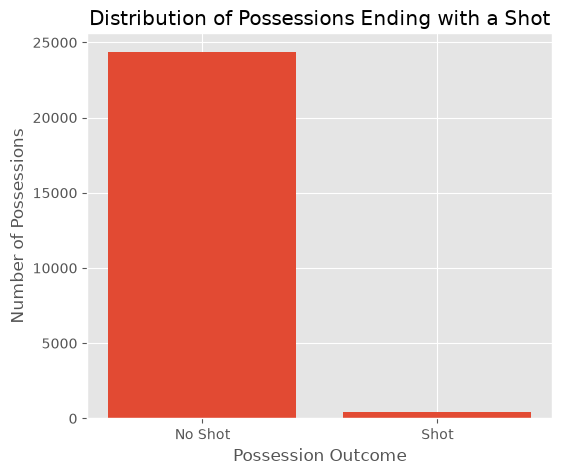

In [12]:
shot_counts = (
    possession_df["ends_with_shot"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,5))

plt.bar(
    ["No Shot", "Shot"],
    shot_counts
)

plt.title("Distribution of Possessions Ending with a Shot")

plt.xlabel("Possession Outcome")

plt.ylabel("Number of Possessions")

plt.show()

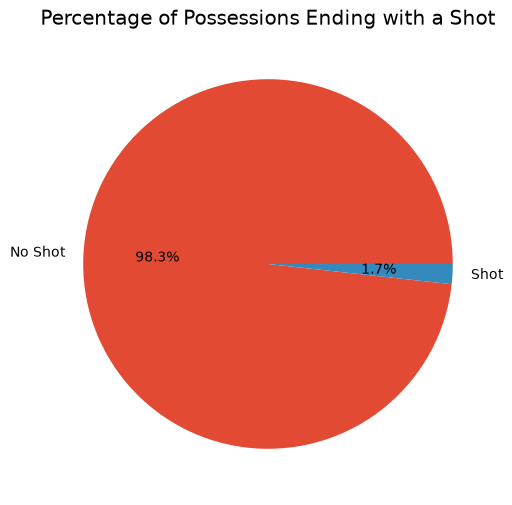

In [13]:
shot_counts.plot(
    kind="pie",
    autopct="%.1f%%",
    labels=["No Shot", "Shot"],
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Percentage of Possessions Ending with a Shot")

plt.show()

## Initial Observations

The target variable is highly imbalanced, with only a relatively small proportion of possessions ending in a shot attempt.

This observation suggests that class imbalance should be considered during predictive modeling and evaluation.

## Possession Duration

Possession duration represents the total time (in seconds) that a team remains in control of the ball during an attacking possession.

Longer possessions may indicate better ball retention, improved build-up play, and greater opportunity to create a shooting chance. This section investigates whether possession duration differs between possessions ending with a shot and those that do not.

In [24]:
possession_df["duration"].describe()

count    24814.000000
mean        18.456748
std         18.834790
min          0.000000
25%          5.449124
50%         12.915356
75%         25.277830
max        244.861856
Name: duration, dtype: float64

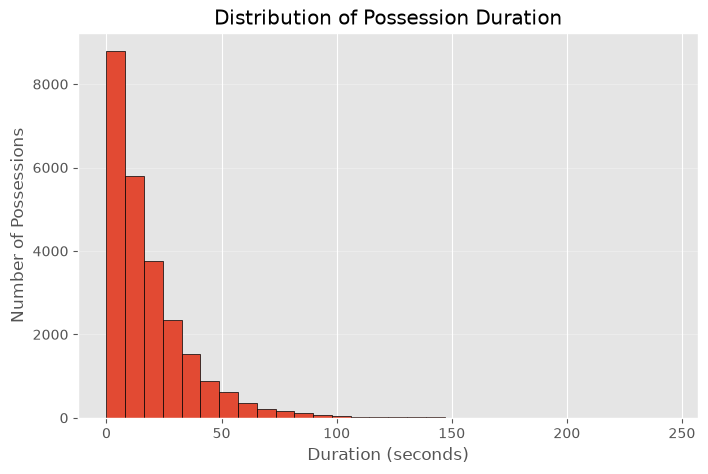

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["duration"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Possession Duration")

plt.xlabel("Duration (seconds)")

plt.ylabel("Number of Possessions")

plt.grid(axis="y", alpha=0.3)

plt.show()

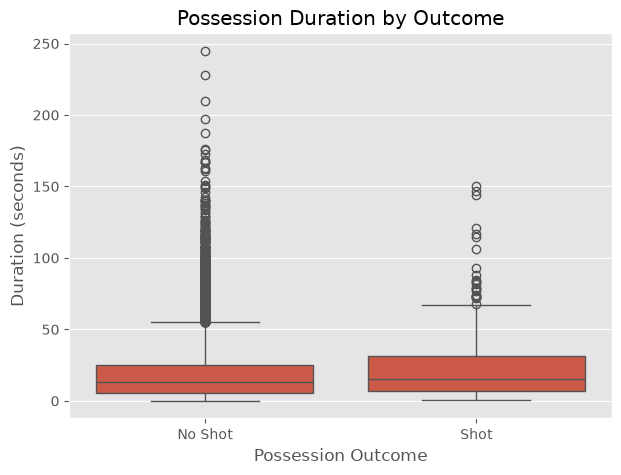

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="duration"
)

plt.xticks(
    [0,1],
    ["No Shot","Shot"]
)

plt.title("Possession Duration by Outcome")

plt.xlabel("Possession Outcome")

plt.ylabel("Duration (seconds)")

plt.show()

In [27]:
duration_summary = (

    possession_df

    .groupby("ends_with_shot")["duration"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

duration_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,18.373403,12.869082,18.729915,0.00000,244.861856
1,433,23.149645,15.301107,23.567660,0.32636,150.073239


In [28]:
shot = possession_df.loc[
    possession_df["ends_with_shot"] == 1,
    "duration"
]

no_shot = possession_df.loc[
    possession_df["ends_with_shot"] == 0,
    "duration"
]

stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)

print(f"U statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

U statistic: 5915035.50
P-value: 0.00002


In [29]:
alpha = 0.05

if p_value < alpha:
    print(
        "There is a statistically significant difference in possession duration."
    )
else:
    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in possession duration.


### Interpretation

Possessions ending with a shot lasted longer on average than possessions without a shot (23.15 seconds vs. 18.37 seconds). The median possession duration also increased from 12.87 to 15.30 seconds.

The Mann–Whitney U test indicated that this difference is statistically significant, suggesting that longer attacking possessions are more likely to result in a shot attempt.

This finding implies that sustaining possession for a longer period may provide teams with additional opportunities to organize attacks and create shooting chances.

## Number of Events

The number of events represents the total actions performed during an attacking possession.

Possessions containing more events may indicate more elaborate build-up play, while shorter sequences may correspond to direct attacks or unsuccessful possessions. This section evaluates whether the complexity of a possession is associated with shot creation.

In [30]:
possession_df["num_events"].describe()

count    24814.000000
mean        19.956033
std         18.440170
min          1.000000
25%          8.000000
50%         15.000000
75%         26.000000
max        229.000000
Name: num_events, dtype: float64

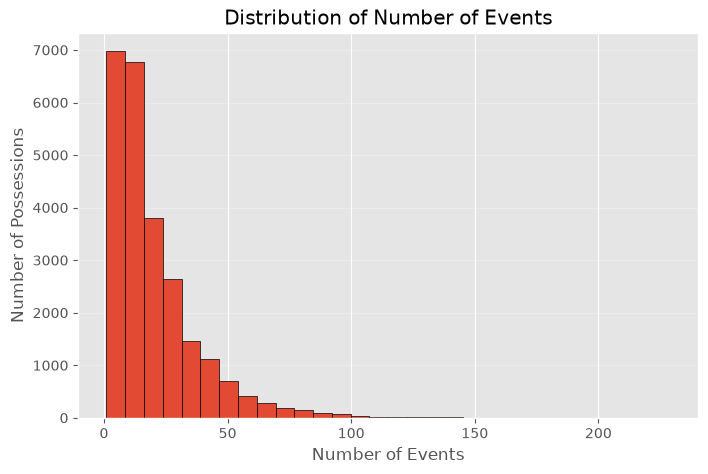

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_events"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Number of Events")

plt.xlabel("Number of Events")

plt.ylabel("Number of Possessions")

plt.grid(axis="y", alpha=0.3)

plt.show()

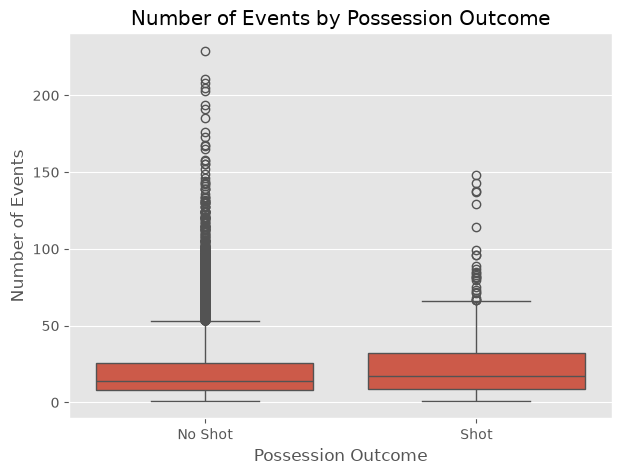

In [32]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_events"
)

plt.xticks(
    [0,1],
    ["No Shot","Shot"]
)

plt.title("Number of Events by Possession Outcome")

plt.xlabel("Possession Outcome")

plt.ylabel("Number of Events")

plt.show()

In [33]:
events_summary = (

    possession_df

    .groupby("ends_with_shot")["num_events"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

events_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,19.869981,14.0,18.328631,1,229
1,433,24.801386,17.0,23.416366,1,148


In [34]:
shot = possession_df.loc[
    possession_df["ends_with_shot"] == 1,
    "num_events"
]

no_shot = possession_df.loc[
    possession_df["ends_with_shot"] == 0,
    "num_events"
]

stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)

print(f"U statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

U statistic: 5922311.50
P-value: 0.00001


In [35]:
if p_value < 0.05:

    print("There is a statistically significant difference in the number of events.")

else:

    print("No statistically significant difference was found.")

There is a statistically significant difference in the number of events.


### Interpretation

Possessions ending with a shot contained a greater number of events than possessions without a shot. On average, shot-ending possessions consisted of 24.80 events compared to 19.87 events for possessions that did not produce a shot.

The Mann–Whitney U test confirmed that this difference is statistically significant.

These results suggest that attacking possessions leading to a shot generally involve more actions, reflecting more elaborate build-up play before a shooting opportunity is created.

## Number of Passes

Passing is the primary mechanism through which teams maintain possession and progress towards the opponent's goal.

This section investigates whether possessions ending with a shot generally involve a greater number of passes than possessions that do not produce a shot.

In [36]:
possession_df["num_passes"].describe()

count    24814.000000
mean         5.382969
std          5.244175
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         59.000000
Name: num_passes, dtype: float64

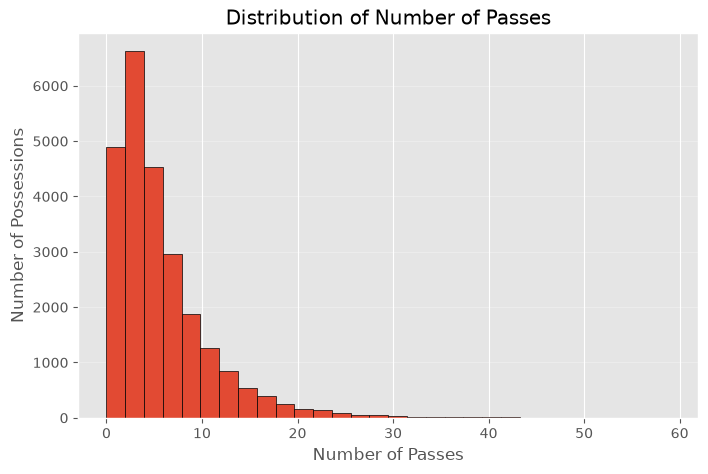

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_passes"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Number of Passes")

plt.xlabel("Number of Passes")

plt.ylabel("Number of Possessions")

plt.grid(axis="y", alpha=0.3)

plt.show()

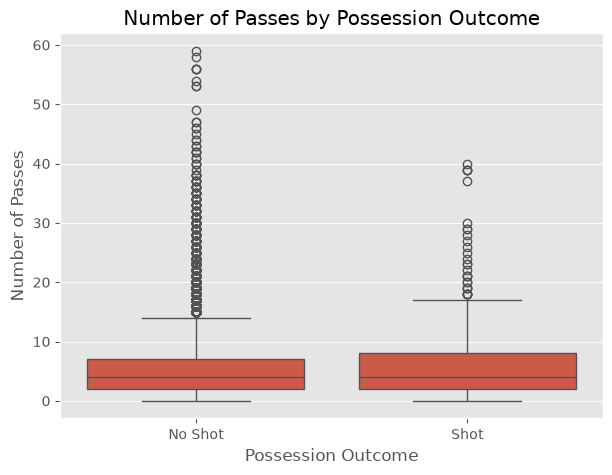

In [38]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_passes"
)

plt.xticks(
    [0,1],
    ["No Shot","Shot"]
)

plt.title("Number of Passes by Possession Outcome")

plt.xlabel("Possession Outcome")

plt.ylabel("Number of Passes")

plt.show()

In [39]:
passes_summary = (

    possession_df

    .groupby("ends_with_shot")["num_passes"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

passes_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,5.367786,4.0,5.214351,0.0,59.0
1,433,6.237875,4.0,6.665017,0.0,40.0


In [40]:
shot = possession_df.loc[
    possession_df["ends_with_shot"] == 1,
    "num_passes"
]

no_shot = possession_df.loc[
    possession_df["ends_with_shot"] == 0,
    "num_passes"
]

stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)

print(f"U statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

U statistic: 5483330.00
P-value: 0.16356


In [41]:
if p_value < 0.05:

    print("There is a statistically significant difference in the number of passes.")

else:

    print("No statistically significant difference was found.")

No statistically significant difference was found.


### Interpretation

Although possessions ending with a shot contained a slightly higher average number of passes than possessions without a shot (6.24 vs. 5.37), the Mann–Whitney U test indicated that this difference is not statistically significant.

This suggests that the quantity of passes alone is not sufficient to distinguish possessions that result in a shot. Other characteristics, such as progression, attacking speed, or spatial advancement, are likely to play a more important role in creating shooting opportunities.

## Progression

Progression measures the forward distance covered during an attacking possession by comparing the starting and ending field positions.

Unlike the number of passes, progression captures how effectively a team advances the ball towards the opponent's goal. Greater progression is expected to increase the probability of creating a shooting opportunity.

In [42]:
possession_df["progression"].describe()

count    24682.000000
mean         7.755996
std         48.394087
min       -119.900000
25%        -13.800000
50%         11.700000
75%         40.900000
max        117.400000
Name: progression, dtype: float64

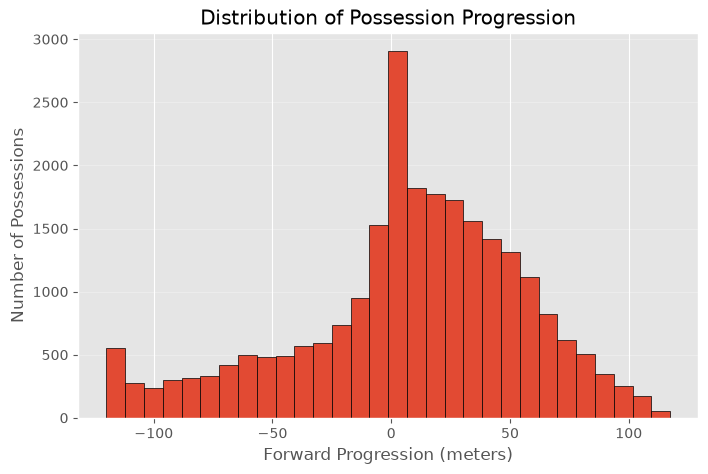

In [43]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["progression"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Possession Progression")

plt.xlabel("Forward Progression (meters)")

plt.ylabel("Number of Possessions")

plt.grid(axis="y", alpha=0.3)

plt.show()

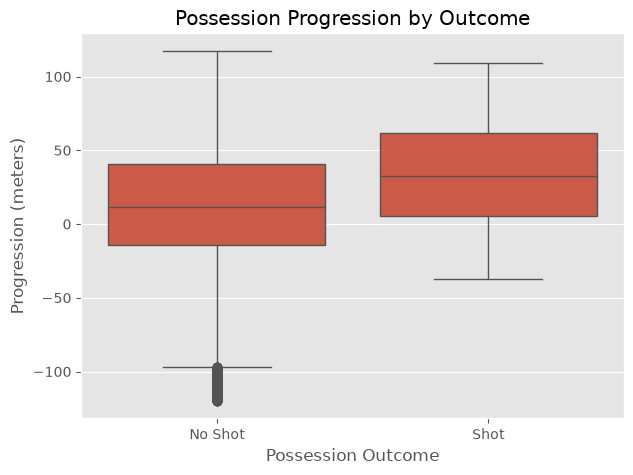

In [44]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="progression"
)

plt.xticks(
    [0,1],
    ["No Shot","Shot"]
)

plt.title("Possession Progression by Outcome")

plt.xlabel("Possession Outcome")

plt.ylabel("Progression (meters)")

plt.show()

In [45]:
progression_summary = (

    possession_df

    .groupby("ends_with_shot")["progression"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

progression_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,7.272176,11.4,48.474526,-119.9,117.4
1,433,34.851039,32.7,34.074398,-37.4,109.2


In [48]:
shot = (
    possession_df
    .loc[
        possession_df["ends_with_shot"] == 1,
        "progression"
    ]
    .dropna()
)

no_shot = (
    possession_df
    .loc[
        possession_df["ends_with_shot"] == 0,
        "progression"
    ]
    .dropna()
)

stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)

print(f"U statistic: {stat:.2f}")
print(f"P-value: {p_value:.5f}")

U statistic: 6861883.50
P-value: 0.00000


In [49]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in progression."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in progression.


### Interpretation

Possessions ending with a shot progressed substantially further towards the opponent's goal than possessions without a shot. On average, shot-ending possessions advanced 34.85 meters, compared to only 7.27 meters for possessions that did not result in a shot. The median progression also increased markedly from 11.4 to 32.7 meters.

The Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001).

This finding suggests that forward territorial advancement is a key characteristic of successful attacking possessions. Compared with the previous analysis of passing activity, the results indicate that the effectiveness of ball progression is more strongly associated with shot creation than the sheer number of completed passes.

## Progression Rate

Progression rate measures the average forward distance covered per second during an attacking possession.

Unlike total progression, this metric reflects the speed at which a team advances the ball towards the opponent's goal. Higher progression rates may indicate faster and more direct attacks, potentially increasing the likelihood of creating a shooting opportunity before the defensive team becomes organized.

In [50]:
possession_df["progression_rate"].describe()

count    23910.000000
mean        -0.176038
std         15.749102
min       -634.911312
25%         -0.867324
50%          0.877568
75%          3.105886
max        527.118879
Name: progression_rate, dtype: float64

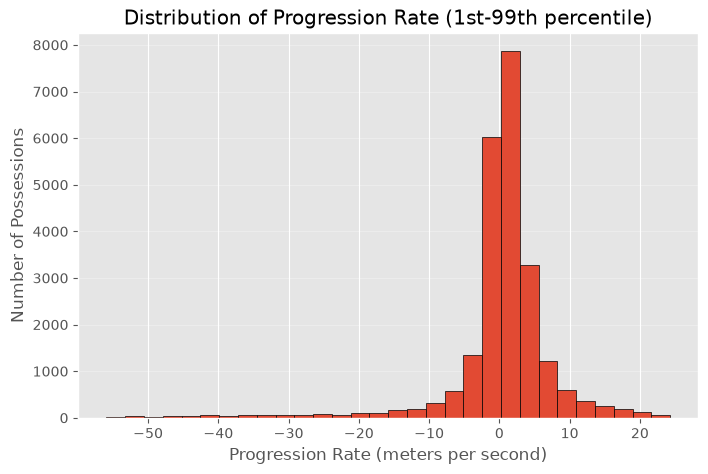

In [57]:
progression_rate_plot = (
    possession_df["progression_rate"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)

lower = progression_rate_plot.quantile(0.01)
upper = progression_rate_plot.quantile(0.99)

progression_rate_plot = progression_rate_plot[
    progression_rate_plot.between(lower, upper)
]


plt.figure(figsize=(8,5))

plt.hist(
    progression_rate_plot,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Progression Rate (1st-99th percentile)")

plt.xlabel("Progression Rate (meters per second)")

plt.ylabel("Number of Possessions")

plt.grid(axis="y", alpha=0.3)

plt.show()

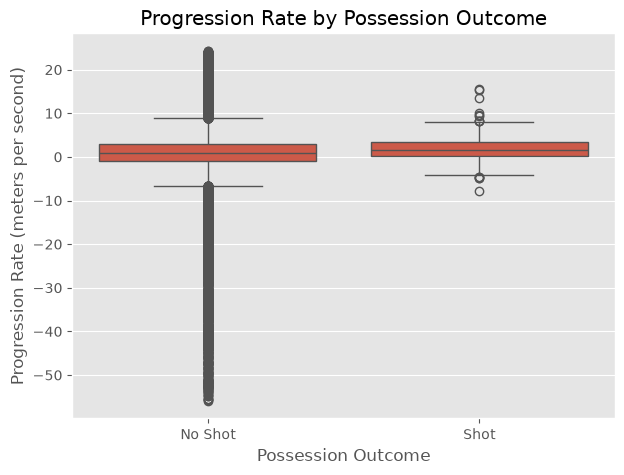

In [58]:
# Create visualization dataframe
plot_df = possession_df.copy()


# Replace infinite values
plot_df["progression_rate"] = (
    plot_df["progression_rate"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# Remove extreme values only for visualization
lower = plot_df["progression_rate"].quantile(0.01)
upper = plot_df["progression_rate"].quantile(0.99)


plot_df = plot_df[
    plot_df["progression_rate"]
    .between(
        lower,
        upper
    )
]


plt.figure(figsize=(7,5))

sns.boxplot(
    data=plot_df,
    x="ends_with_shot",
    y="progression_rate"
)


plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)


plt.title(
    "Progression Rate by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Progression Rate (meters per second)"
)


plt.show()

In [53]:
progression_rate_summary = (

    plot_df

    .groupby("ends_with_shot")["progression_rate"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

progression_rate_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,23477,-0.215395,0.863008,15.881541,-634.911312,527.118879
1,433,1.957825,1.566424,4.038910,-7.870493,56.992278


In [54]:
shot = (

    plot_df

    .loc[
        plot_df["ends_with_shot"] == 1,
        "progression_rate"
    ]

    .dropna()

)

no_shot = (

    plot_df

    .loc[
        plot_df["ends_with_shot"] == 0,
        "progression_rate"
    ]

    .dropna()

)

stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)

print(f"U statistic: {stat:.2f}")

print(f"P-value: {p_value:.5f}")

U statistic: 5805227.00
P-value: 0.00000


In [55]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in progression rate."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in progression rate.


### Interpretation

Possessions ending with a shot exhibited a considerably higher progression rate than possessions without a shot. On average, shot-ending possessions advanced 1.96 meters per second, whereas possessions without a shot showed an average progression rate close to zero.

The Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001).

These findings suggest that not only the total forward advancement, but also the speed at which teams progress the ball, plays an important role in creating shooting opportunities. Faster attacking progression appears to be a distinguishing characteristic of possessions that successfully culminate in a shot.

## Pass Ratio

Pass ratio represents the proportion of passing actions relative to the total number of events within a possession.

This feature describes the attacking style of a possession by measuring how dominant passing is compared with other actions such as carries, dribbles, and duels.

The analysis investigates whether the structure of possession differs between attacks that result in a shot and those that do not.

In [59]:
possession_df["pass_ratio"].describe()

count    24814.000000
mean         0.269034
std          0.126974
min          0.000000
25%          0.217391
50%          0.272727
75%          0.320000
max          1.000000
Name: pass_ratio, dtype: float64

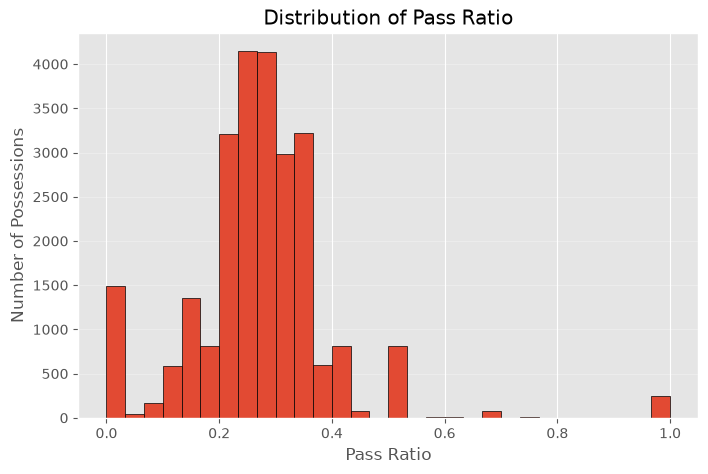

In [60]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["pass_ratio"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Pass Ratio"
)

plt.xlabel(
    "Pass Ratio"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

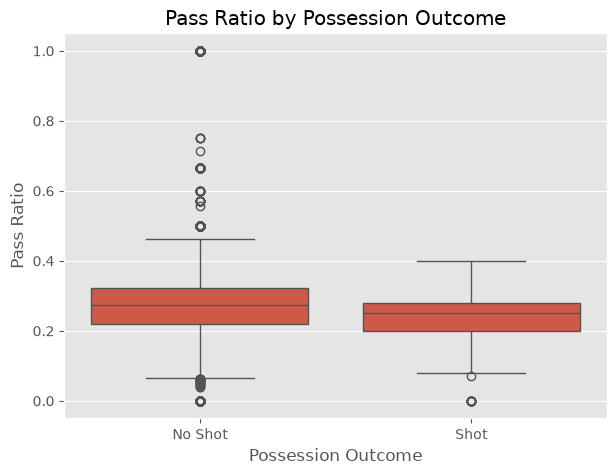

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="pass_ratio"
)


plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)


plt.title(
    "Pass Ratio by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Pass Ratio"
)


plt.show()

In [62]:
pass_ratio_summary = (

    possession_df

    .groupby("ends_with_shot")["pass_ratio"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

pass_ratio_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,0.269682,0.272727,0.127650,0.0,1.0
1,433,0.232557,0.250000,0.071358,0.0,0.4


In [63]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "pass_ratio"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "pass_ratio"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 4016283.50
P-value: 0.00000


In [64]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in pass ratio."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in pass ratio.


### Interpretation

Possessions ending with a shot showed a lower pass ratio compared with possessions that did not result in a shot (0.233 vs. 0.270).

The Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001).

These results suggest that shot creation is not necessarily associated with a higher proportion of passing actions. Instead, successful attacking possessions appear to involve a more varied action profile, where progression, ball carrying, and direct attacking actions contribute alongside passing.

Combined with the previous finding that total number of passes was not significantly different between possession outcomes, this indicates that the structure and effectiveness of possession are more important than passing volume alone.

## Number of Carries

Ball carries represent actions where a player advances the ball while maintaining possession.

Unlike passing actions, carries directly reflect individual ball progression and movement with the ball. This section investigates whether possessions ending with a shot contain more carrying actions compared with possessions that do not create a shooting opportunity.

In [65]:
possession_df["progression_rate"].describe()

count    23910.000000
mean        -0.176038
std         15.749102
min       -634.911312
25%         -0.867324
50%          0.877568
75%          3.105886
max        527.118879
Name: progression_rate, dtype: float64

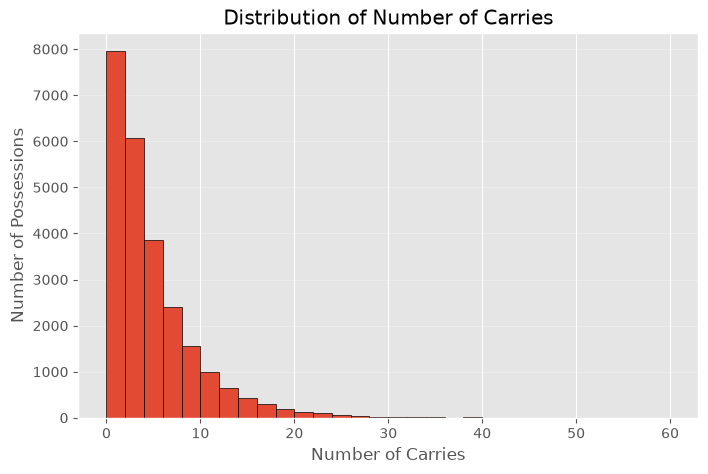

In [66]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_carries"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Carries"
)

plt.xlabel(
    "Number of Carries"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

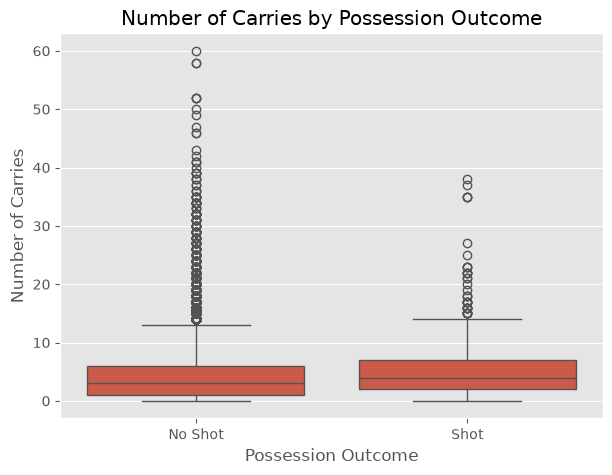

In [67]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_carries"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Number of Carries by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Carries"
)

plt.show()

In [68]:
carries_summary = (

    possession_df

    .groupby("ends_with_shot")["num_carries"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

carries_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,4.349042,3.0,4.880145,0.0,60.0
1,433,5.630485,4.0,6.216927,0.0,38.0


In [69]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_carries"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_carries"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5890991.50
P-value: 0.00003


In [70]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in the number of carries."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in the number of carries.


### Interpretation

Possessions ending with a shot contained a higher number of carries compared with possessions that did not produce a shot. Shot-ending possessions included an average of 5.63 carries, while possessions without a shot included 4.35 carries.

The median number of carries was also higher for shot-ending possessions (4 compared with 3).

The Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001).

These findings suggest that ball carrying contributes to the creation of shooting opportunities. Combined with the previous results for progression and progression rate, this indicates that direct ball advancement actions play an important role in successful attacking possessions.

The results also support the earlier finding that a higher proportion of passing actions alone does not characterize more successful attacks.

## Number of Dribbles

Dribbles represent individual attacking actions where a player attempts to bypass an opponent while maintaining possession.

This feature captures individual creativity and the ability to break defensive structures. The analysis investigates whether possessions ending with a shot involve more dribbling actions compared with possessions that do not create a shooting opportunity.

In [71]:
possession_df["num_dribbles"].describe()

count    24814.000000
mean         0.164625
std          0.436446
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: num_dribbles, dtype: float64

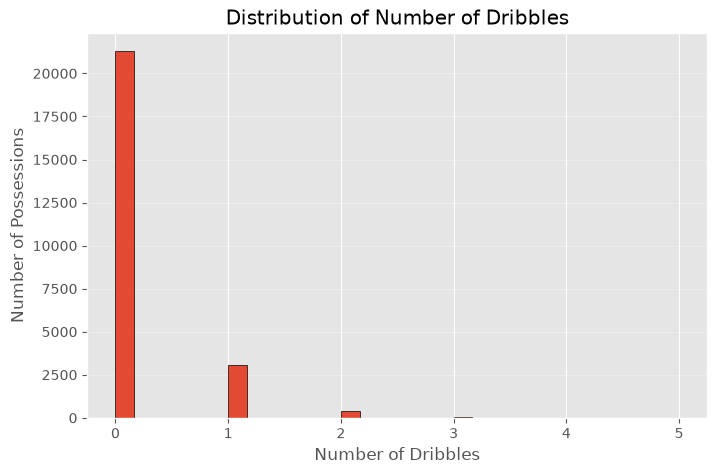

In [72]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_dribbles"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Dribbles"
)

plt.xlabel(
    "Number of Dribbles"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

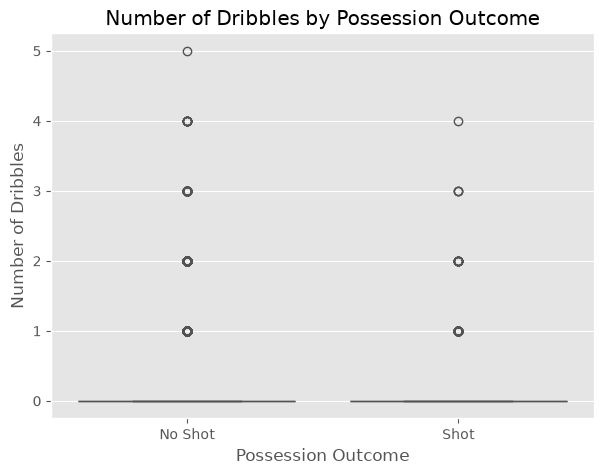

In [73]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_dribbles"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Number of Dribbles by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Dribbles"
)

plt.show()

In [77]:
dribble_presence = (
    possession_df
    .assign(
        has_dribble = possession_df["num_dribbles"] > 0
    )
    .groupby("ends_with_shot")["has_dribble"]
    .mean()
    * 100
)

dribble_presence

ends_with_shot
0    14.097043
1    19.861432
Name: has_dribble, dtype: float64

In [74]:
dribbles_summary = (

    possession_df

    .groupby("ends_with_shot")["num_dribbles"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

dribbles_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,0.162996,0.0,0.433344,0.0,5.0
1,433,0.256351,0.0,0.578442,0.0,4.0


In [75]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_dribbles"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_dribbles"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5597573.50
P-value: 0.00036


In [76]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in the number of dribbles."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in the number of dribbles.


### Interpretation

Dribbling actions occurred relatively infrequently across possessions, with the majority of possessions containing no dribble attempts. However, possessions ending with a shot showed a higher frequency of dribbling activity compared with possessions without a shot.

The average number of dribbles was higher in shot-ending possessions (0.26 vs. 0.16), while approximately 19.9% of shot-ending possessions contained at least one dribble compared with 14.1% of possessions without a shot.

Although the median value was equal for both groups (0 dribbles), the Mann–Whitney U test identified a statistically significant difference between the distributions (p < 0.001).

These results suggest that individual actions aimed at eliminating defenders can contribute to the creation of shooting opportunities. However, because dribbles occur relatively rarely, they appear to represent a supporting attacking mechanism rather than the main driver of successful possession outcomes.

Combined with the previous findings for progression and carries, the results indicate that successful attacking possessions are primarily characterized by effective ball advancement, with dribbling providing an additional method for creating space and disrupting defensive organization.

## Pressure Events

Pressure events represent defensive pressure applied during an attacking possession.

This feature captures the level of defensive resistance faced by the attacking team. The analysis investigates whether possessions ending with a shot experience a different level of pressure compared with possessions that do not result in a shooting opportunity.

In [78]:
possession_df["pressure_events"].describe()

count    24814.000000
mean         4.360804
std          4.432765
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         50.000000
Name: pressure_events, dtype: float64

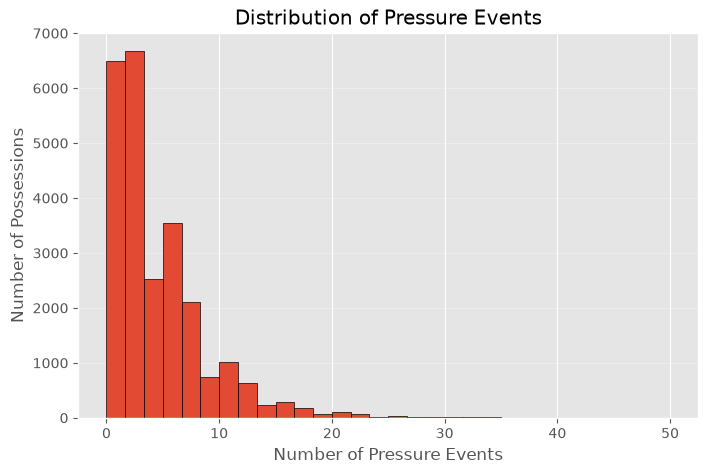

In [79]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["pressure_events"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Pressure Events"
)

plt.xlabel(
    "Number of Pressure Events"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

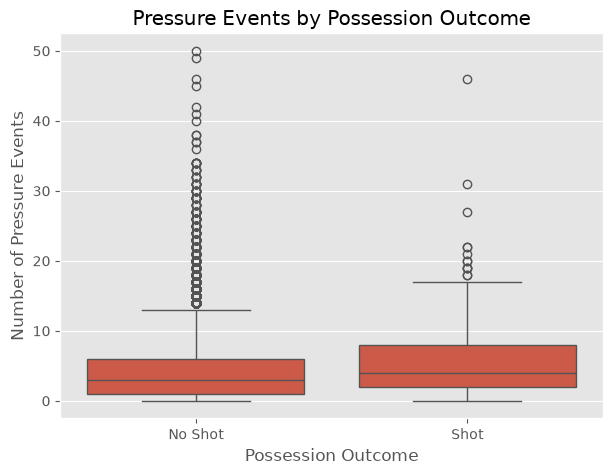

In [80]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="pressure_events"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Pressure Events by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Pressure Events"
)

plt.show()

In [81]:
pressure_summary = (

    possession_df

    .groupby("ends_with_shot")["pressure_events"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

pressure_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,4.340921,3.0,4.411904,0.0,50.0
1,433,5.480370,4.0,5.369255,0.0,46.0


In [82]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "pressure_events"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "pressure_events"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5930307.50
P-value: 0.00001


In [83]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in pressure events."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in pressure events.


### Interpretation

Possessions ending with a shot experienced a higher number of pressure events compared with possessions without a shot. Shot-ending possessions contained an average of 5.48 pressure events, while possessions without a shot contained 4.34 pressure events.

The median number of pressure events was also higher for shot-ending possessions (4 compared with 3).

The Mann–Whitney U test confirmed that this difference is statistically significant (p < 0.001).

These results indicate that successful attacking possessions are not necessarily characterized by avoiding defensive pressure. Instead, shot-ending possessions appear to involve more active interactions under pressure, suggesting that teams are able to maintain possession, progress the ball, and create shooting opportunities despite defensive resistance.

Combined with previous findings for progression and carries, this suggests that successful possessions are defined by the ability to advance and execute attacking actions under challenging defensive conditions.

## Number of Turnovers

Turnovers represent possession-ending actions where the attacking team loses control of the ball.

This feature captures unsuccessful possession outcomes and provides insight into whether ball retention is associated with creating shooting opportunities.

The analysis compares the number of turnovers between possessions ending with a shot and possessions without a shot.

In [85]:
possession_df["num_turnovers"].describe()

count    24814.000000
mean         0.328282
std          0.594708
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: num_turnovers, dtype: float64

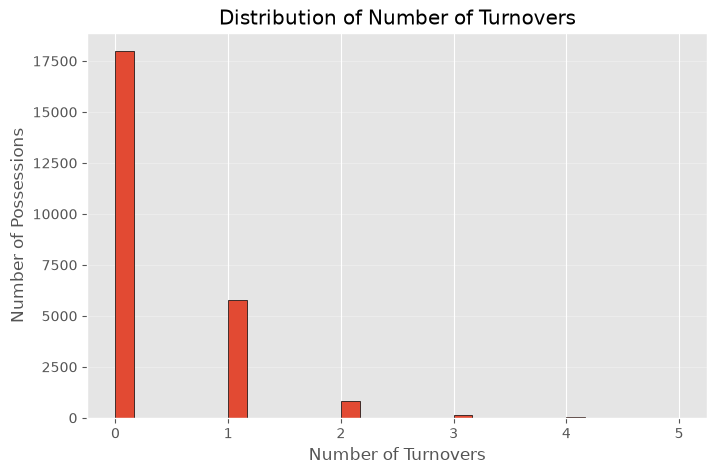

In [86]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_turnovers"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Turnovers"
)

plt.xlabel(
    "Number of Turnovers"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

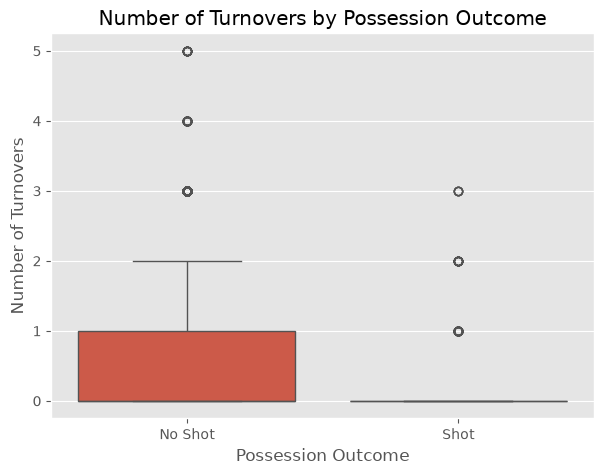

In [87]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_turnovers"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Number of Turnovers by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Turnovers"
)

plt.show()

In [88]:
turnovers_summary = (

    possession_df

    .groupby("ends_with_shot")["num_turnovers"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

turnovers_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,0.330749,0.0,0.595610,0.0,5.0
1,433,0.189376,0.0,0.523678,0.0,3.0


In [89]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_turnovers"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_turnovers"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 4573972.50
P-value: 0.00000


In [90]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in turnovers."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in turnovers.


### Interpretation

Possessions that did not result in a shot contained a higher number of turnovers compared with shot-ending possessions.

The average number of turnovers was higher for possessions without a shot (0.33) compared with possessions ending with a shot (0.19). Although the median value was zero for both groups, the distributions showed a statistically significant difference according to the Mann–Whitney U test (p < 0.001).

These results indicate that maintaining possession control is an important characteristic of attacking sequences that create shooting opportunities. Possessions interrupted by turnovers are less likely to progress into a final attacking action.

Combined with previous findings for progression, carries, and pressure events, this suggests that successful attacking possessions require both positive actions to advance the ball and the ability to avoid losing possession before reaching a shot opportunity.

## Number of Dispossessed Actions

Dispossessed actions represent situations where an attacking player loses possession after being challenged by an opponent.

This feature captures unsuccessful individual actions and defensive disruption. The analysis investigates whether possessions ending with a shot contain fewer dispossessions compared with possessions that do not create a shooting opportunity.

In [91]:
possession_df["num_dispossessed"].describe()

count    24814.000000
mean         0.150157
std          0.403233
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: num_dispossessed, dtype: float64

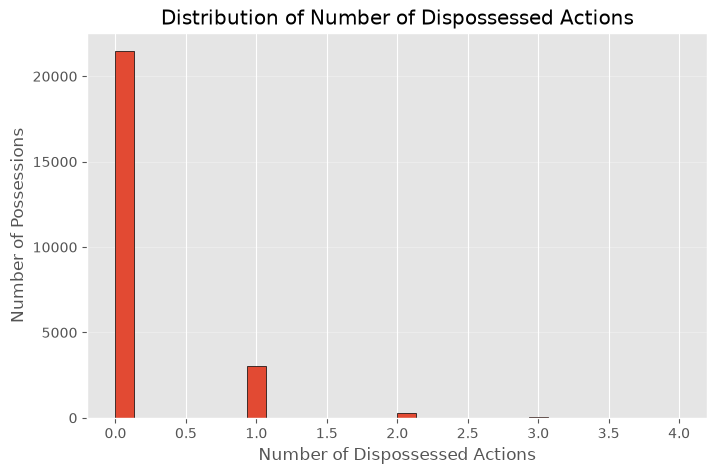

In [92]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_dispossessed"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Dispossessed Actions"
)

plt.xlabel(
    "Number of Dispossessed Actions"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

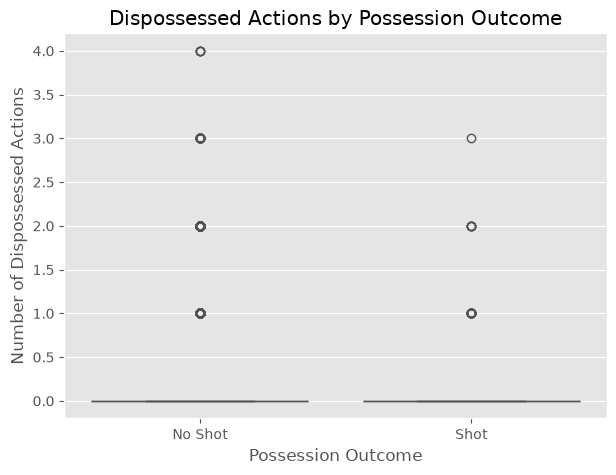

In [93]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_dispossessed"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Dispossessed Actions by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Dispossessed Actions"
)

plt.show()

In [97]:
dispossessed_presence = (
    
    possession_df
    .assign(
        has_dispossessed = possession_df["num_dispossessed"] > 0
    )
    .groupby("ends_with_shot")["has_dispossessed"]
    .mean()
    * 100

)

dispossessed_presence

ends_with_shot
0    13.559739
1     8.775982
Name: has_dispossessed, dtype: float64

In [94]:
dispossessed_summary = (

    possession_df

    .groupby("ends_with_shot")["num_dispossessed"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

dispossessed_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,0.150978,0.0,0.403901,0.0,4.0
1,433,0.103926,0.0,0.361079,0.0,3.0


In [95]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_dispossessed"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_dispossessed"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5029695.50
P-value: 0.00445


In [96]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in dispossessed actions."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in dispossessed actions.


### Interpretation

Possessions without a shot contained a higher number of dispossessed actions compared with possessions ending with a shot.

The average number of dispossessions was higher for possessions without a shot (0.15) compared with shot-ending possessions (0.10). Although the median value was zero for both groups, the Mann–Whitney U test identified a statistically significant difference between the distributions (p < 0.001).

These results suggest that maintaining individual ball control is associated with a higher likelihood of reaching a shooting opportunity. Possessions that end with a shot appear to involve fewer situations where players lose the ball directly to defensive challenges.

However, compared with progression and carrying actions, dispossessions represent a secondary factor, describing possession stability rather than attacking creation itself.

## Number of Miscontrols

Miscontrols represent technical errors where a player fails to properly control the ball during a possession.

This feature captures execution quality and ball retention ability. The analysis investigates whether possessions ending with a shot contain fewer miscontrol events compared with possessions that do not create a shooting opportunity.

In [98]:
possession_df["num_miscontrols"].describe()

count    24814.000000
mean         0.178125
std          0.423805
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: num_miscontrols, dtype: float64

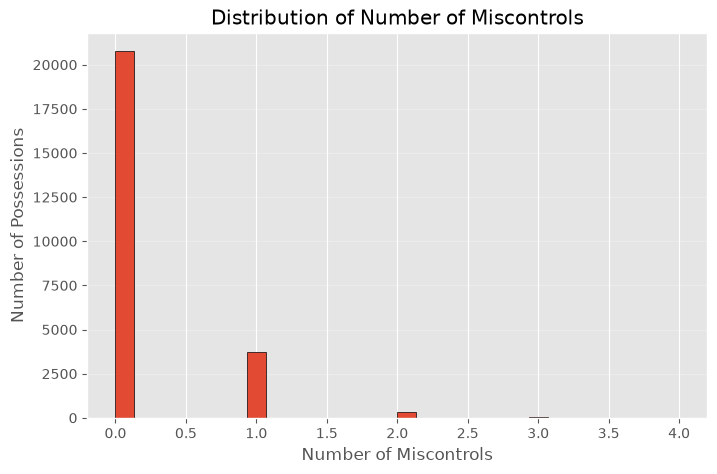

In [99]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_miscontrols"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Miscontrols"
)

plt.xlabel(
    "Number of Miscontrols"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [106]:
miscontrol_presence = (

    possession_df

    .assign(
        has_miscontrol = possession_df["num_miscontrols"] > 0
    )

    .groupby("ends_with_shot")["has_miscontrol"]

    .mean()

    * 100

)

miscontrol_presence

ends_with_shot
0    16.463640
1     7.621247
Name: has_miscontrol, dtype: float64

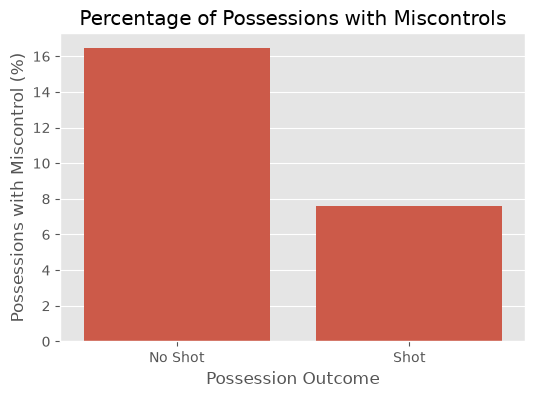

In [105]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=miscontrol_presence.index,
    y=miscontrol_presence.values
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Percentage of Possessions with Miscontrols"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Possessions with Miscontrol (%)"
)

plt.show()

In [101]:
miscontrols_summary = (

    possession_df

    .groupby("ends_with_shot")["num_miscontrols"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

miscontrols_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,0.179771,0.0,0.425358,0.0,4.0
1,433,0.085450,0.0,0.311204,0.0,2.0


In [102]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_miscontrols"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_miscontrols"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 4814184.50
P-value: 0.00000


In [103]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in miscontrols."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in miscontrols.


### Interpretation

Miscontrol events were less frequent in possessions that ended with a shot compared with possessions without a shot.

The average number of miscontrols was lower for shot-ending possessions (0.09) compared with possessions without a shot (0.18). Additionally, only 7.6% of shot-ending possessions contained at least one miscontrol, compared with 16.5% of possessions without a shot.

The Mann–Whitney U test confirmed that the difference between the two distributions was statistically significant (p < 0.001).

These results suggest that technical execution and ball control quality are important characteristics of successful attacking possessions. Possessions that maintain cleaner execution are more likely to continue developing toward a final shooting action.

Together with the previous findings for turnovers and dispossessions, this indicates that possession stability is an important component of shot creation, alongside positive attacking actions such as progression and ball carrying.

## Possession Starting Location (start_x)

The starting location of a possession provides information about where attacking sequences begin on the pitch.

Higher x-values represent more advanced field positions, closer to the opponent's goal. This analysis investigates whether possessions ending with a shot begin from different areas of the pitch compared with possessions without a shot.

In [107]:
possession_df["start_x"].describe()

count    24682.000000
mean        49.809545
std         34.271488
min          0.100000
25%         19.300000
50%         48.200000
75%         72.700000
max        120.000000
Name: start_x, dtype: float64

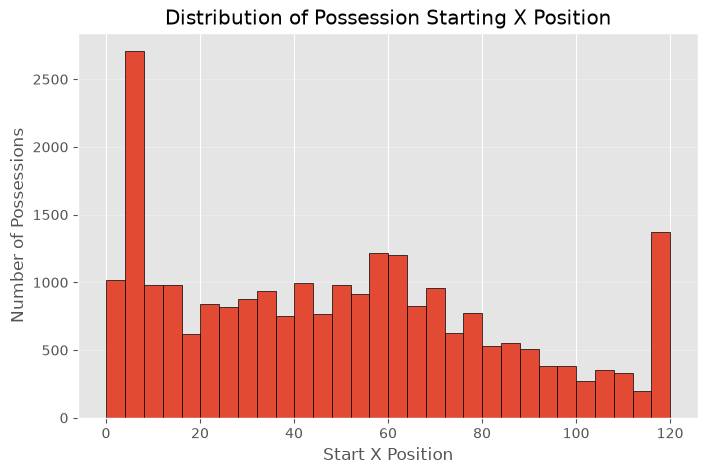

In [108]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["start_x"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Starting X Position"
)

plt.xlabel(
    "Start X Position"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

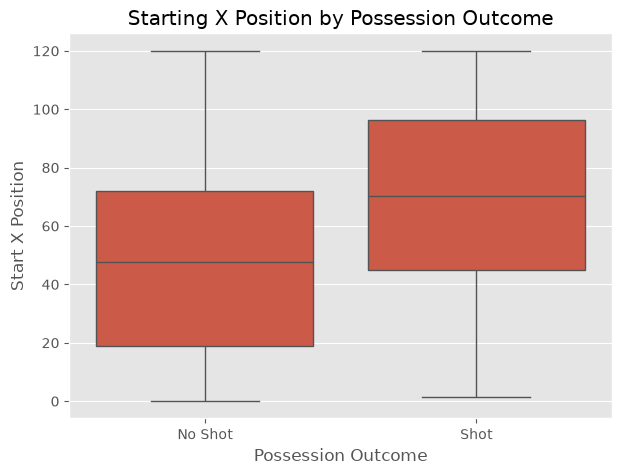

In [109]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="start_x"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Starting X Position by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Start X Position"
)

plt.show()

In [110]:
start_x_summary = (

    possession_df

    .groupby("ends_with_shot")["start_x"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

start_x_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,49.456514,47.7,34.161707,0.1,120.0
1,433,69.580139,70.4,34.643377,1.6,120.0


In [111]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "start_x"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "start_x"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 6966569.50
P-value: 0.00000


In [112]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in start_x between possession outcomes."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in start_x between possession outcomes.


### Interpretation

The starting location of possessions showed a strong difference between possessions ending with a shot and those without a shot.

Shot-ending possessions started from significantly higher x-positions, with an average starting location of 69.6 compared with 49.5 for possessions without a shot. The median starting position was also higher for shot-ending possessions (70.4 vs. 47.7).

The Mann–Whitney U test confirmed that this difference was statistically significant (p < 0.001).

These results indicate that possessions beginning in more advanced areas of the pitch are more likely to result in a shooting opportunity. Starting location therefore represents an important spatial characteristic of attacking effectiveness.

Combined with previous findings for progression and ball advancement, this suggests that both the origin and development of a possession influence the likelihood of creating a shot.

## Possession Ending Location (end_x)

The ending location of a possession describes where the attacking sequence finishes on the pitch.

Higher x-values represent more advanced positions closer to the opponent's goal. This analysis investigates whether possessions ending with a shot reach more advanced areas compared with possessions that do not produce a shooting opportunity.

In [113]:
possession_df["end_x"].describe()

count    24682.000000
mean        57.565542
std         36.226979
min          0.100000
25%         25.925000
50%         60.000000
75%         88.200000
max        120.000000
Name: end_x, dtype: float64

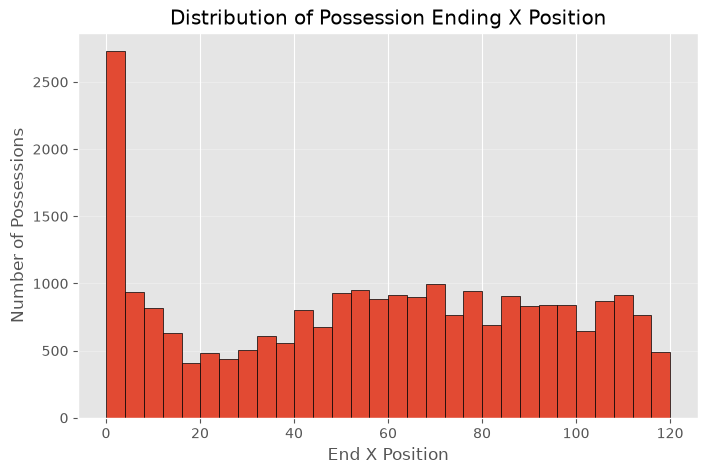

In [114]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["end_x"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Ending X Position"
)

plt.xlabel(
    "End X Position"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

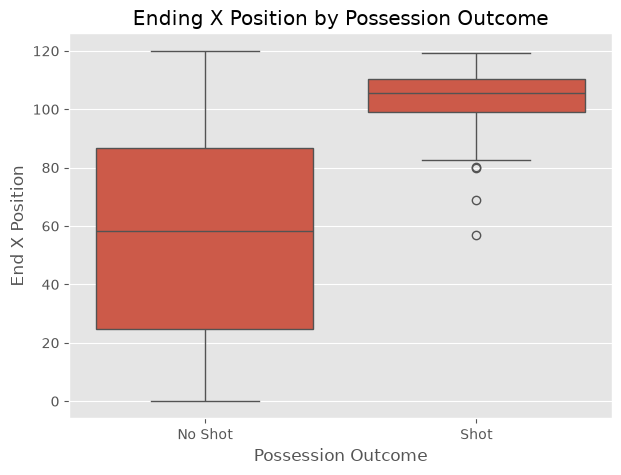

In [115]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="end_x"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Ending X Position by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "End X Position"
)

plt.show()

In [116]:
end_x_summary = (

    possession_df

    .groupby("ends_with_shot")["end_x"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

end_x_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,56.728690,58.3,35.982191,0.1,120.0
1,433,104.431178,105.7,8.172901,56.8,119.2


In [117]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "end_x"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "end_x"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 9352391.00
P-value: 0.00000


In [118]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in end_x between possession outcomes."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in end_x between possession outcomes.


### Interpretation

The ending location of possessions showed a very strong difference between possessions ending with a shot and those without a shot.

Shot-ending possessions finished significantly higher on the pitch, with an average end_x value of 104.4 compared with 56.7 for possessions without a shot. The median ending location was also substantially higher for shot-ending possessions (105.7 vs. 58.3).

The Mann–Whitney U test confirmed that this difference was statistically significant (p < 0.001).

The low variation among shot-ending possessions (standard deviation = 8.17) indicates that these possessions consistently reach advanced attacking areas before producing a shot. In contrast, possessions without a shot finish across a much wider range of locations.

These findings highlight the importance of territorial advancement and reaching dangerous areas of the pitch as key characteristics of successful attacking possessions.

## Possession Progression Distance

Progression distance measures the amount of horizontal space gained during a possession.

It is calculated as the difference between the ending and starting x-position of the possession:

progression_distance = end_x - start_x

Positive values indicate that the possession moved towards the opponent's goal, while smaller or negative values represent limited advancement or backward movement.

This analysis investigates whether possessions ending with a shot achieve greater territorial progression compared with possessions without a shot.

In [119]:
possession_df["progression_distance"] = (

    possession_df["end_x"]

    - possession_df["start_x"]

)


possession_df[
    [
        "start_x",
        "end_x",
        "progression_distance"
    ]
].head()

,start_x,end_x,progression_distance
0,NaN,NaN,NaN
1,61.0,64.4,3.4
2,48.1,65.3,17.2
3,69.0,67.4,-1.6
4,67.6,112.6,45.0


In [120]:
possession_df["progression_distance"] = (

    possession_df["end_x"]

    - possession_df["start_x"]

)


possession_df[
    [
        "start_x",
        "end_x",
        "progression_distance"
    ]
].head()

,start_x,end_x,progression_distance
0,NaN,NaN,NaN
1,61.0,64.4,3.4
2,48.1,65.3,17.2
3,69.0,67.4,-1.6
4,67.6,112.6,45.0


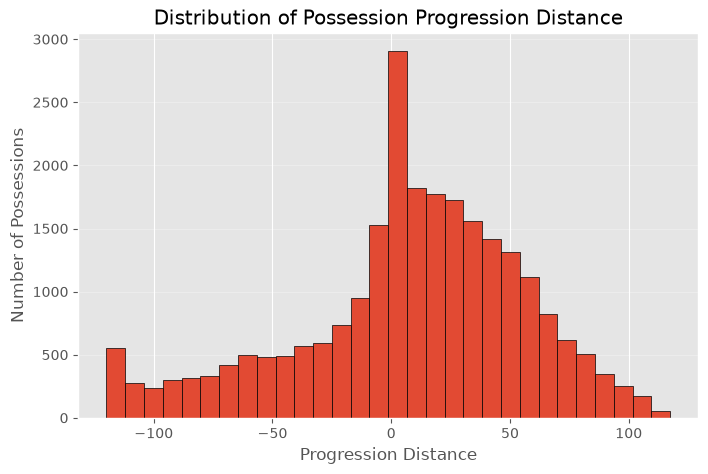

In [121]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["progression_distance"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Progression Distance"
)

plt.xlabel(
    "Progression Distance"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

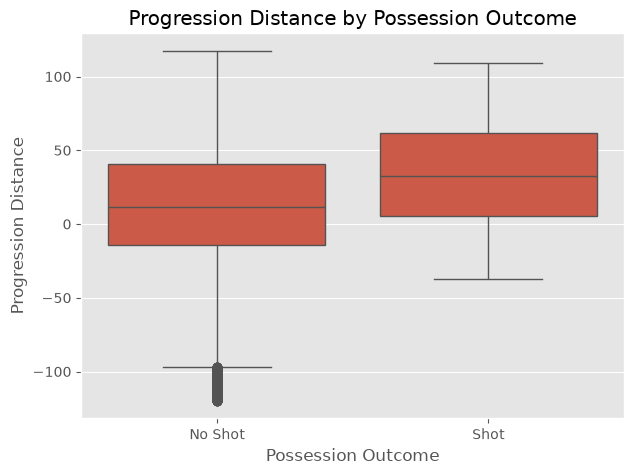

In [122]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="progression_distance"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Progression Distance by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Progression Distance"
)

plt.show()

In [123]:
progression_distance_summary = (

    possession_df

    .groupby("ends_with_shot")["progression_distance"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

progression_distance_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,7.272176,11.4,48.474526,-119.9,117.4
1,433,34.851039,32.7,34.074398,-37.4,109.2


In [124]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "progression_distance"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "progression_distance"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 6861833.00
P-value: 0.00000


In [125]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in progression distance between possession outcomes."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in progression distance between possession outcomes.


### Interpretation

Possession progression distance showed one of the strongest differences between possessions ending with a shot and those without a shot.

Shot-ending possessions achieved substantially greater territorial advancement, with an average progression distance of 34.9 compared with only 7.3 for possessions without a shot. The median progression distance was also considerably higher for shot-ending possessions (32.7 vs. 11.4).

The Mann–Whitney U test confirmed that the difference between the two distributions was statistically significant (p < 0.001).

These results indicate that advancing the ball towards the opponent's goal is a major characteristic of successful attacking possessions. Possessions that create shooting opportunities are not only starting and ending in more advanced areas, but also gain significantly more territory during their development.

Together with the previous findings for start_x, end_x, and progression_rate, this demonstrates that spatial advancement is one of the strongest indicators of attacking effectiveness.

## Possession Starting Width Position (start_y)

The y-coordinate represents the lateral position where a possession begins.

While x-position describes progression towards the opponent's goal, y-position describes the width of the pitch. This analysis investigates whether possessions ending with a shot start from different lateral areas compared with possessions without a shot.

In [126]:
possession_df["start_y"].describe()

count    24682.000000
mean        40.447865
std         27.694461
min          0.100000
25%         15.700000
50%         40.000000
75%         66.200000
max         80.000000
Name: start_y, dtype: float64

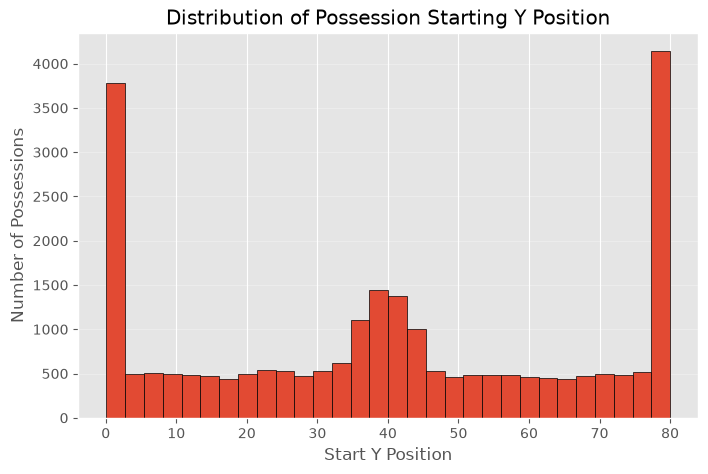

In [127]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["start_y"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Starting Y Position"
)

plt.xlabel(
    "Start Y Position"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

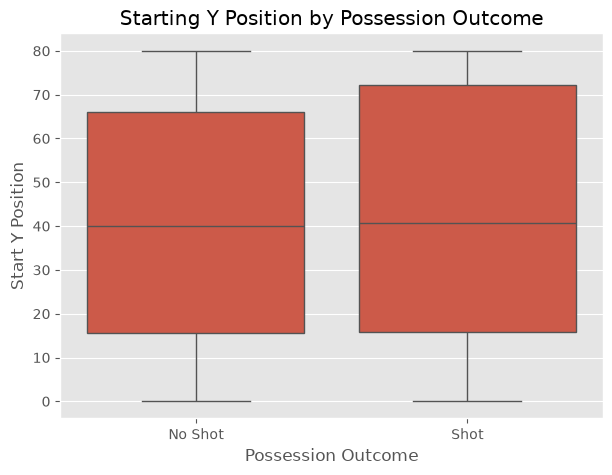

In [128]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="start_y"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Starting Y Position by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Start Y Position"
)

plt.show()

In [129]:
start_y_summary = (

    possession_df

    .groupby("ends_with_shot")["start_y"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

start_y_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,40.421749,40.0,27.670695,0.1,80.0
1,433,41.910393,40.6,28.990175,0.1,80.0


In [130]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "start_y"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "start_y"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5412472.50
P-value: 0.26689


In [131]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in start_y between possession outcomes."
    )

else:

    print(
        "No statistically significant difference was found."
    )

No statistically significant difference was found.


### Interpretation

The starting y-position did not show a statistically significant difference between possessions ending with a shot and those without a shot.

The average starting y-position was very similar between the two groups (41.9 for shot-ending possessions and 40.4 for possessions without a shot). The Mann–Whitney U test confirmed that the difference was not statistically significant (p = 0.267).

These findings suggest that the lateral starting position of a possession is not a major factor distinguishing successful attacking sequences from unsuccessful ones.

Compared with the strong influence of x-position and territorial progression, the width of the pitch where a possession begins appears to play a smaller role in determining whether the possession produces a shot.

## Possession Ending Width Position (end_y)

The ending y-coordinate represents the lateral position where a possession finishes.

While x-position describes progression towards the opponent's goal, y-position captures the final width location of the possession. This analysis investigates whether possessions ending with a shot finish in different lateral areas compared with possessions without a shot.

In [132]:
possession_df["end_y"].describe()

count    24682.000000
mean        39.932813
std         24.382331
min          0.100000
25%         17.900000
50%         39.900000
75%         61.900000
max         80.000000
Name: end_y, dtype: float64

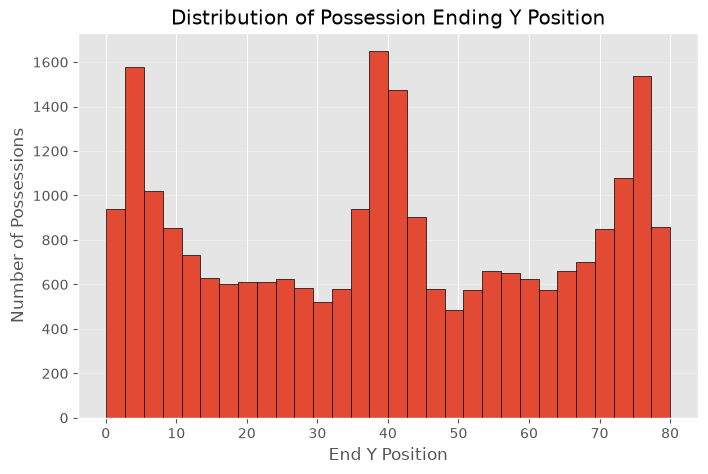

In [133]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["end_y"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Ending Y Position"
)

plt.xlabel(
    "End Y Position"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

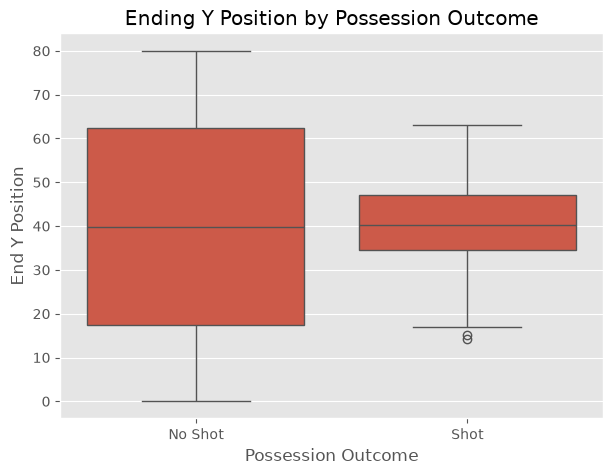

In [134]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="end_y"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Ending Y Position by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "End Y Position"
)

plt.show()

In [135]:
end_y_summary = (

    possession_df

    .groupby("ends_with_shot")["end_y"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

end_y_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,39.924620,39.9,24.567997,0.1,80.0
1,433,40.391686,40.3,9.248254,14.3,63.0


In [136]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "end_y"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "end_y"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5320504.50
P-value: 0.63096


In [137]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in end_y between possession outcomes."
    )

else:

    print(
        "No statistically significant difference was found."
    )

No statistically significant difference was found.


### Interpretation

The ending y-position did not show a statistically significant difference between possessions ending with a shot and those without a shot.

The average ending width position was almost identical between the two groups (40.4 for shot-ending possessions and 39.9 for possessions without a shot). The Mann–Whitney U test confirmed that this difference was not statistically significant (p = 0.631).

These findings indicate that the lateral finishing location of a possession is not a major factor distinguishing successful attacking sequences.

Compared with the strong influence of forward progression and advanced pitch positioning, the width of the final possession location appears to have a limited impact on whether a possession results in a shot.

## Possession Ending Pitch Zones

To provide a more tactical interpretation of spatial progression, possession ending locations were divided into three pitch zones:

- Defensive third (0–40)
- Middle third (40–80)
- Final third (80–120)

This analysis examines whether possessions ending with a shot reach more advanced areas of the pitch more frequently.

In [146]:
def classify_zone(x):

    if pd.isna(x):
        return np.nan

    elif x < 40:
        return "Defensive Third"

    elif x < 80:
        return "Middle Third"

    else:
        return "Final Third"


possession_df["end_zone"] = (
    possession_df["end_x"]
    .apply(classify_zone)
)


possession_df[
    [
        "end_x",
        "end_zone"
    ]
].head()

,end_x,end_zone
0,NaN,NaN
1,64.4,Middle Third
2,65.3,Middle Third
3,67.4,Middle Third
4,112.6,Final Third


In [147]:
zone_distribution = (

    possession_df

    .groupby(
        [
            "ends_with_shot",
            "end_zone"
        ]
    )

    .size()

)

zone_distribution

ends_with_shot  end_zone       
0               Defensive Third    8102
                Final Third        7392
                Middle Third       8755
1               Final Third         430
                Middle Third          3
dtype: int64

In [152]:
zone_percentage = (

    possession_df

    .groupby("ends_with_shot")["end_zone"]

    .value_counts(normalize=True)

    * 100

)


zone_percentage

ends_with_shot  end_zone       
0               Middle Third       36.104582
                Defensive Third    33.411687
                Final Third        30.483731
1               Final Third        99.307159
                Middle Third        0.692841
Name: proportion, dtype: float64

In [153]:
zone_percentage_df = (

    zone_percentage

    .rename("percentage")

    .reset_index()

)


zone_percentage_df

,ends_with_shot,end_zone,percentage
0,0,Middle Third,36.104582
1,0,Defensive Third,33.411687
2,0,Final Third,30.483731
3,1,Final Third,99.307159
4,1,Middle Third,0.692841


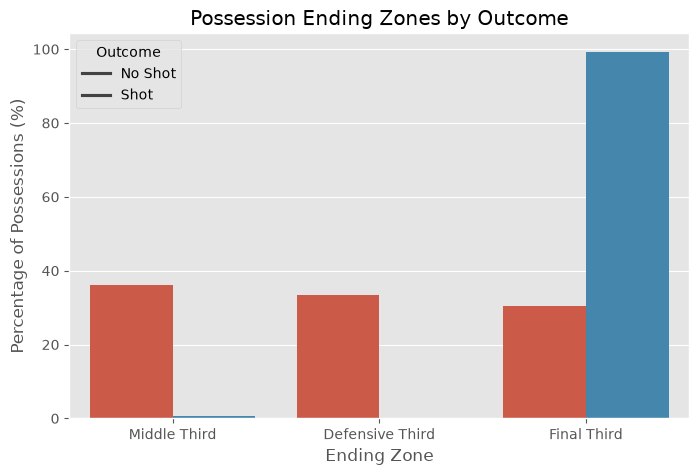

In [150]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=zone_percentage_df,
    x="end_zone",
    y="percentage",
    hue="ends_with_shot"
)


plt.title(
    "Possession Ending Zones by Outcome"
)

plt.xlabel(
    "Ending Zone"
)

plt.ylabel(
    "Percentage of Possessions (%)"
)


plt.legend(
    title="Outcome",
    labels=[
        "No Shot",
        "Shot"
    ]
)

plt.show()

In [154]:
final_third_analysis = (

    possession_df

    .assign(
        reaches_final_third =
        possession_df["end_x"] >= 80
    )

    .groupby("ends_with_shot")["reaches_final_third"]

    .mean()

    * 100

)


final_third_analysis

ends_with_shot
0    30.318691
1    99.307159
Name: reaches_final_third, dtype: float64

### Interpretation

The pitch zone analysis revealed a very strong relationship between possession ending location and shot creation.

Possessions ending with a shot almost exclusively reached the final third, with 99.3% of shot-ending possessions finishing in the final third of the pitch. Only 0.7% ended in the middle third, while none finished in the defensive third.

In comparison, possessions without a shot showed a much more balanced distribution, with only 30.5% reaching the final third. The remaining possessions ended in the defensive or middle thirds, indicating that many attacking sequences fail to progress into dangerous areas.

These findings confirm that reaching advanced attacking zones is a critical characteristic of successful attacking possessions. Combined with the previous results for end_x, start_x, and progression distance, this demonstrates that territorial advancement is one of the strongest indicators associated with shot creation.

## Number of Players Involved

The number of players involved in a possession describes the level of player participation during an attacking sequence.

A higher number of involved players may indicate more complex and collective attacking patterns, while lower values may represent more direct or individual actions.

This analysis investigates whether possessions ending with a shot involve a different number of players compared with possessions without a shot.

In [156]:
possession_df["num_players"].describe()

count    24814.000000
mean         6.980737
std          4.052127
min          0.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         22.000000
Name: num_players, dtype: float64

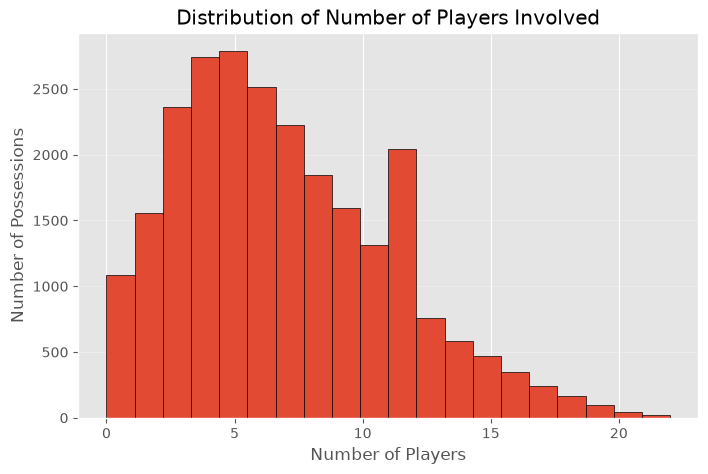

In [157]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["num_players"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title(
    "Distribution of Number of Players Involved"
)

plt.xlabel(
    "Number of Players"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

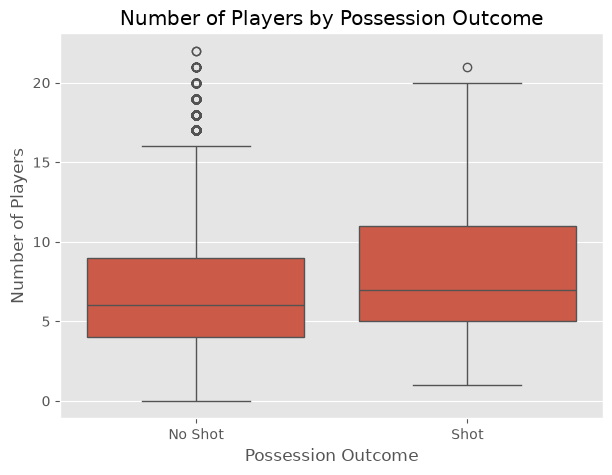

In [158]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="num_players"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Number of Players by Possession Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Number of Players"
)

plt.show()

In [159]:
players_summary = (

    possession_df

    .groupby("ends_with_shot")["num_players"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

players_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24381,6.961158,6.0,4.040739,0,22
1,433,8.083141,7.0,4.518738,1,21


In [160]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "num_players"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "num_players"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5992899.50
P-value: 0.00000


In [161]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in number of players involved."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in number of players involved.


### Interpretation

The number of players involved showed a statistically significant difference between possessions ending with a shot and those without a shot.

Shot-ending possessions involved a higher average number of players (8.1) compared with possessions without a shot (7.0). The median value was also slightly higher for shot-ending possessions (7 vs. 6).

The Mann–Whitney U test confirmed that the difference between the two distributions was statistically significant (p < 0.001).

These findings suggest that successful attacking possessions tend to involve a greater level of player participation. Rather than relying only on individual actions, shot-producing possessions are more frequently associated with collective involvement and coordinated attacking sequences.

However, compared with spatial progression variables such as end_x and progression distance, player involvement appears to be a supporting characteristic rather than the primary driver of shot creation.

## Possession Time per Player

Possession time per player combines possession duration and player involvement to measure how much time is spent relative to the number of players participating.

This feature provides insight into whether shooting opportunities are created through direct actions involving fewer players or through more collective attacking sequences involving multiple players.

In [162]:
possession_df["possession_time_per_player"] = (

    possession_df["duration"]

    /

    possession_df["num_players"].replace(
        0,
        np.nan
    )

)


possession_df[
    [
        "duration",
        "num_players",
        "possession_time_per_player"
    ]
].head()

,duration,num_players,possession_time_per_player
0,0.000000,0,NaN
1,21.920786,7,3.131541
2,49.032388,12,4.086032
3,2.093451,2,1.046725
4,25.660795,10,2.566080


In [169]:
possession_df["possession_time_per_player"].describe()

count    24339.000000
mean         2.300964
std          1.430501
min          0.000000
25%          1.312150
50%          2.088715
75%          3.021307
max         30.322962
Name: possession_time_per_player, dtype: float64

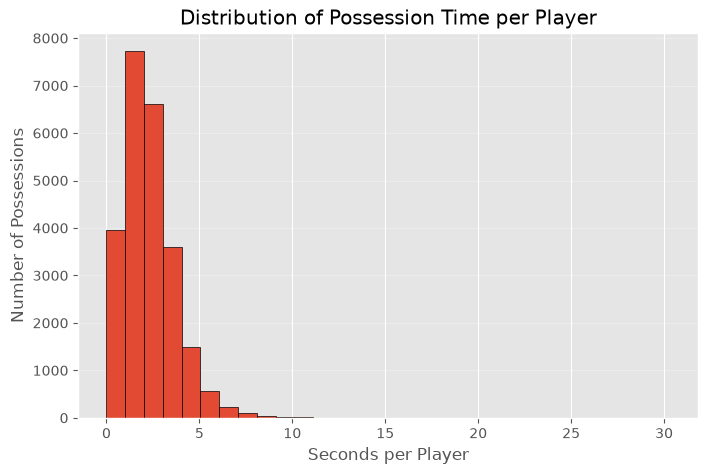

In [164]:
plt.figure(figsize=(8,5))

plt.hist(
    possession_df["possession_time_per_player"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribution of Possession Time per Player"
)

plt.xlabel(
    "Seconds per Player"
)

plt.ylabel(
    "Number of Possessions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

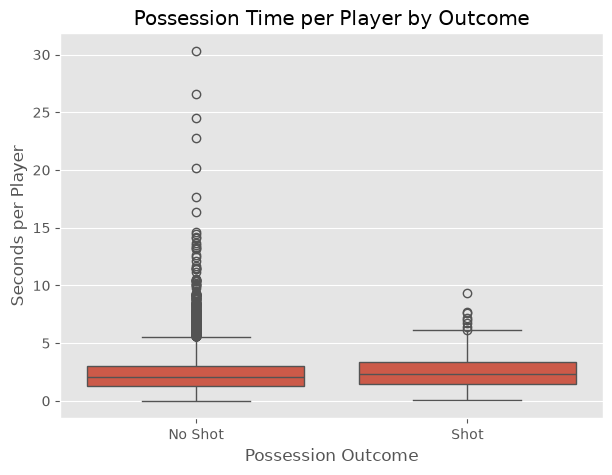

In [165]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=possession_df,
    x="ends_with_shot",
    y="possession_time_per_player"
)

plt.xticks(
    [0,1],
    [
        "No Shot",
        "Shot"
    ]
)

plt.title(
    "Possession Time per Player by Outcome"
)

plt.xlabel(
    "Possession Outcome"
)

plt.ylabel(
    "Seconds per Player"
)

plt.show()

In [166]:
time_player_summary = (

    possession_df

    .groupby("ends_with_shot")["possession_time_per_player"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

time_player_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,23906,2.297620,2.085958,1.431241,0.00000,30.322962
1,433,2.485588,2.290924,1.378071,0.08159,9.379577


In [167]:
shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 1,
        "possession_time_per_player"
    ]

    .dropna()

)


no_shot = (

    possession_df

    .loc[
        possession_df["ends_with_shot"] == 0,
        "possession_time_per_player"
    ]

    .dropna()

)


stat, p_value = mannwhitneyu(
    shot,
    no_shot,
    alternative="two-sided"
)


print(
    f"U statistic: {stat:.2f}"
)

print(
    f"P-value: {p_value:.5f}"
)

U statistic: 5634378.00
P-value: 0.00155


In [168]:
if p_value < 0.05:

    print(
        "There is a statistically significant difference in possession time per player."
    )

else:

    print(
        "No statistically significant difference was found."
    )

There is a statistically significant difference in possession time per player.


### Interpretation

Possession time per player showed a statistically significant difference between possessions ending with a shot and those without a shot.

Shot-ending possessions had a slightly higher average possession time per player (2.49 seconds) compared with possessions without a shot (2.30 seconds). The median value showed a similar pattern (2.29 vs. 2.09 seconds).

The Mann–Whitney U test confirmed that the difference between the two distributions was statistically significant (p = 0.00155).

These findings suggest that shot-producing possessions involve slightly longer periods of involvement relative to the number of participating players. This may indicate more structured attacking sequences where multiple players remain involved during possession development.

However, the magnitude of the difference is relatively small compared with spatial indicators such as end_x and progression distance, suggesting that time-based complexity is a secondary characteristic of successful attacking possessions.

In [173]:
eda_features = [

    "duration",
    "num_events",
    "num_passes",
    "progression",
    "progression_rate",
    "num_carries",
    "num_dribbles",
    "pass_ratio",
    "num_turnovers",
    "num_dispossessed",
    "num_miscontrols",
    "start_x",
    "end_x",
    "progression_distance",
    "num_players",
    "possession_time_per_player"

]

In [174]:
eda_features = [

    feature

    for feature in eda_features

    if feature in possession_df.columns

]


eda_features

['duration',
 'num_events',
 'num_passes',
 'progression',
 'progression_rate',
 'num_carries',
 'num_dribbles',
 'pass_ratio',
 'num_turnovers',
 'num_dispossessed',
 'num_miscontrols',
 'start_x',
 'end_x',
 'progression_distance',
 'num_players',
 'possession_time_per_player']

In [175]:
from scipy.stats import mannwhitneyu


summary_results = []


for feature in eda_features:

    shot = (

        possession_df

        .loc[
            possession_df["ends_with_shot"] == 1,
            feature
        ]

        .dropna()

    )


    no_shot = (

        possession_df

        .loc[
            possession_df["ends_with_shot"] == 0,
            feature
        ]

        .dropna()

    )


    u_stat, p_value = mannwhitneyu(

        shot,

        no_shot,

        alternative="two-sided"

    )


    summary_results.append(

        {

            "feature": feature,

            "no_shot_mean": no_shot.mean(),

            "shot_mean": shot.mean(),

            "difference": shot.mean() - no_shot.mean(),

            "p_value": p_value,

            "u_statistic": u_stat

        }

    )


eda_summary = pd.DataFrame(summary_results)


eda_summary

,feature,no_shot_mean,shot_mean,difference,p_value,u_statistic
0,duration,18.373403,23.149645,4.776242,1.645153e-05,5915035.5
1,num_events,19.869981,24.801386,4.931405,1.304954e-05,5922311.5
2,num_passes,5.367786,6.237875,0.870089,1.635557e-01,5483330.0
3,progression,7.272176,34.851039,27.578863,5.370146e-28,6861883.5
4,progression_rate,-0.215395,1.957825,2.173220,3.850587e-07,5805227.0
5,num_carries,4.349042,5.630485,1.281443,3.003302e-05,5890991.5
6,num_dribbles,0.162996,0.256351,0.093355,3.605518e-04,5597573.5
7,pass_ratio,0.269682,0.232557,-0.037124,1.221159e-17,4016283.5
8,num_turnovers,0.330749,0.189376,-0.141373,9.273521e-10,4573972.5
9,num_dispossessed,0.150978,0.103926,-0.047052,4.450979e-03,5029695.5


In [176]:
eda_summary["significant"] = (

    eda_summary["p_value"]

    <

    0.05

)


eda_summary

,feature,no_shot_mean,shot_mean,difference,p_value,u_statistic,significant
0,duration,18.373403,23.149645,4.776242,1.645153e-05,5915035.5,True
1,num_events,19.869981,24.801386,4.931405,1.304954e-05,5922311.5,True
2,num_passes,5.367786,6.237875,0.870089,1.635557e-01,5483330.0,False
3,progression,7.272176,34.851039,27.578863,5.370146e-28,6861883.5,True
4,progression_rate,-0.215395,1.957825,2.173220,3.850587e-07,5805227.0,True
5,num_carries,4.349042,5.630485,1.281443,3.003302e-05,5890991.5,True
6,num_dribbles,0.162996,0.256351,0.093355,3.605518e-04,5597573.5,True
7,pass_ratio,0.269682,0.232557,-0.037124,1.221159e-17,4016283.5,True
8,num_turnovers,0.330749,0.189376,-0.141373,9.273521e-10,4573972.5,True
9,num_dispossessed,0.150978,0.103926,-0.047052,4.450979e-03,5029695.5,True


In [177]:
eda_summary.sort_values(

    by="difference",

    ascending=False

)

,feature,no_shot_mean,shot_mean,difference,p_value,u_statistic,significant
12,end_x,56.728690,104.431178,47.702488,1.721970e-171,9352391.0,True
3,progression,7.272176,34.851039,27.578863,5.370146e-28,6861883.5,True
13,progression_distance,7.272176,34.851039,27.578863,5.390609e-28,6861833.0,True
11,start_x,49.456514,69.580139,20.123625,1.569745e-31,6966569.5,True
1,num_events,19.869981,24.801386,4.931405,1.304954e-05,5922311.5,True
0,duration,18.373403,23.149645,4.776242,1.645153e-05,5915035.5,True
4,progression_rate,-0.215395,1.957825,2.173220,3.850587e-07,5805227.0,True
5,num_carries,4.349042,5.630485,1.281443,3.003302e-05,5890991.5,True
14,num_players,6.961158,8.083141,1.121983,1.225877e-06,5992899.5,True
2,num_passes,5.367786,6.237875,0.870089,1.635557e-01,5483330.0,False


In [178]:
eda_summary.sort_values(

    by="p_value"

)

,feature,no_shot_mean,shot_mean,difference,p_value,u_statistic,significant
12,end_x,56.728690,104.431178,47.702488,1.721970e-171,9352391.0,True
11,start_x,49.456514,69.580139,20.123625,1.569745e-31,6966569.5,True
3,progression,7.272176,34.851039,27.578863,5.370146e-28,6861883.5,True
13,progression_distance,7.272176,34.851039,27.578863,5.390609e-28,6861833.0,True
7,pass_ratio,0.269682,0.232557,-0.037124,1.221159e-17,4016283.5,True
8,num_turnovers,0.330749,0.189376,-0.141373,9.273521e-10,4573972.5,True
4,progression_rate,-0.215395,1.957825,2.173220,3.850587e-07,5805227.0,True
10,num_miscontrols,0.179771,0.085450,-0.094321,9.354484e-07,4814184.5,True
14,num_players,6.961158,8.083141,1.121983,1.225877e-06,5992899.5,True
1,num_events,19.869981,24.801386,4.931405,1.304954e-05,5922311.5,True


In [179]:
eda_summary.round(3)

,feature,no_shot_mean,shot_mean,difference,p_value,u_statistic,significant
0,duration,18.373,23.150,4.776,0.000,5915035.5,True
1,num_events,19.870,24.801,4.931,0.000,5922311.5,True
2,num_passes,5.368,6.238,0.870,0.164,5483330.0,False
3,progression,7.272,34.851,27.579,0.000,6861883.5,True
4,progression_rate,-0.215,1.958,2.173,0.000,5805227.0,True
5,num_carries,4.349,5.630,1.281,0.000,5890991.5,True
6,num_dribbles,0.163,0.256,0.093,0.000,5597573.5,True
7,pass_ratio,0.270,0.233,-0.037,0.000,4016283.5,True
8,num_turnovers,0.331,0.189,-0.141,0.000,4573972.5,True
9,num_dispossessed,0.151,0.104,-0.047,0.004,5029695.5,True


In [180]:
final_features = [

    "start_x",

    "end_x",

    "progression_distance",

    "duration",

    "num_events",

    "num_players",

    "num_carries",

    "num_turnovers",

    "num_miscontrols"

]

## Exploratory Analysis Summary

The exploratory analysis revealed that spatial progression was the strongest characteristic distinguishing possessions that resulted in shots from those that did not.

The largest differences were observed in ending pitch position, progression distance, and starting pitch position. Possessions leading to shots consistently reached more advanced areas of the pitch and gained significantly more territory.

Additional differences were observed in possession complexity, including duration, number of events, player involvement, and carries, suggesting that successful attacking sequences tend to involve more developed collective actions.

Ball security indicators also showed significant differences, with shot-ending possessions recording fewer turnovers, dispossessions, and miscontrols.

Interestingly, the total number of passes alone did not significantly distinguish possession outcomes, indicating that possession quality is determined more by progression and execution than by passing volume.

# Machine Learning Prediction of Shot Outcome

Based on the exploratory analysis, several possession characteristics showed significant differences between possessions ending with a shot and those without a shot.

The selected features focus on:

- spatial progression,
- possession development,
- player involvement,
- ball security.

A binary classification approach is used, where the target variable is whether a possession ends with a shot.

In [181]:
final_features = [

    "start_x",
    "end_x",
    "progression_distance",
    "duration",
    "num_events",
    "num_players",
    "num_carries",
    "num_turnovers",
    "num_miscontrols"

]

In [182]:
X = possession_df[final_features]

y = possession_df["ends_with_shot"]

In [183]:
X.head()

,start_x,end_x,progression_distance,duration,num_events,num_players,num_carries,num_turnovers,num_miscontrols
0,NaN,NaN,NaN,0.000000,4,0,0.0,0.0,0.0
1,61.0,64.4,3.4,21.920786,21,7,6.0,0.0,0.0
2,48.1,65.3,17.2,49.032388,68,12,14.0,1.0,1.0
3,69.0,67.4,-1.6,2.093451,5,2,1.0,0.0,0.0
4,67.6,112.6,45.0,25.660795,28,10,7.0,0.0,0.0


In [184]:
y.value_counts()

ends_with_shot
0    24381
1      433
Name: count, dtype: int64

In [185]:
X.isna().sum()

start_x                 132
end_x                   132
progression_distance    132
duration                  0
num_events                0
num_players               0
num_carries               0
num_turnovers             0
num_miscontrols           0
dtype: int64

In [186]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(
    strategy="median"
)


X_imputed = pd.DataFrame(

    imputer.fit_transform(X),

    columns=X.columns

)


X_imputed.head()

,start_x,end_x,progression_distance,duration,num_events,num_players,num_carries,num_turnovers,num_miscontrols
0,48.2,60.0,11.7,0.000000,4.0,0.0,0.0,0.0,0.0
1,61.0,64.4,3.4,21.920786,21.0,7.0,6.0,0.0,0.0
2,48.1,65.3,17.2,49.032388,68.0,12.0,14.0,1.0,1.0
3,69.0,67.4,-1.6,2.093451,5.0,2.0,1.0,0.0,0.0
4,67.6,112.6,45.0,25.660795,28.0,10.0,7.0,0.0,0.0


In [187]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X_imputed,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [188]:
print(
    y_train.value_counts(normalize=True)
)

print(
    y_test.value_counts(normalize=True)
)

ends_with_shot
0    0.98257
1    0.01743
Name: proportion, dtype: float64
ends_with_shot
0    0.98247
1    0.01753
Name: proportion, dtype: float64


In [189]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression(

    max_iter=1000,

    class_weight="balanced"

)


log_model.fit(

    X_train,

    y_train

)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [191]:
start_y_summary = (

    possession_df

    .groupby("ends_with_shot")["start_y"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )

)

start_y_summary

,count,mean,median,std,min,max
ends_with_shot,,,,,,
0,24249,40.421749,40.0,27.670695,0.1,80.0
1,433,41.910393,40.6,28.990175,0.1,80.0


In [190]:
y_pred = log_model.predict(X_test)

y_prob = log_model.predict_proba(X_test)[:,1]

In [192]:
from sklearn.metrics import (

    classification_report,

    roc_auc_score,

    confusion_matrix

)


print(
    classification_report(
        y_test,
        y_pred
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)


confusion_matrix(
    y_test,
    y_pred
)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4876
           1       0.07      0.95      0.14        87

    accuracy                           0.79      4963
   macro avg       0.54      0.87      0.51      4963
weighted avg       0.98      0.79      0.87      4963

ROC-AUC: 0.9110751228159505


array([[3849, 1027],
       [   4,   83]])

In [193]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced",

    max_depth=8

)


rf_model.fit(

    X_train,

    y_train

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [194]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [195]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)


confusion_matrix(
    y_test,
    rf_pred
)

              precision    recall  f1-score   support

           0       1.00      0.85      0.92      4876
           1       0.09      0.87      0.17        87

    accuracy                           0.85      4963
   macro avg       0.54      0.86      0.54      4963
weighted avg       0.98      0.85      0.90      4963

ROC-AUC: 0.9246049145238702


array([[4129,  747],
       [  11,   76]])

In [196]:
feature_importance = pd.DataFrame(

    {
        "feature": X_train.columns,

        "importance": rf_model.feature_importances_

    }

)


feature_importance = feature_importance.sort_values(

    by="importance",

    ascending=False

)


feature_importance

,feature,importance
1,end_x,0.646948
2,progression_distance,0.140139
0,start_x,0.070135
3,duration,0.041339
5,num_players,0.029759
4,num_events,0.028506
7,num_turnovers,0.023389
6,num_carries,0.015218
8,num_miscontrols,0.004568


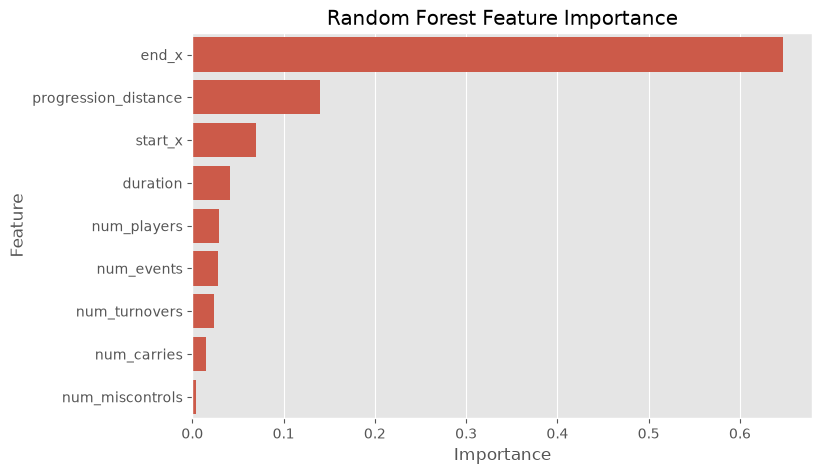

In [197]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=feature_importance,

    x="importance",

    y="feature"

)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

## Feature Importance Analysis

The Random Forest model identified spatial progression variables as the strongest predictors of shot outcome.

The most influential feature was end_x, accounting for the majority of model importance. This indicates that the final location of a possession on the pitch is the strongest indicator of whether a possession will result in a shot.

Progression distance and start_x were the next most important features, confirming the importance of territorial advancement and attacking positioning.

Other variables related to possession complexity, including duration, number of players involved, and event count, contributed additional predictive value but had substantially lower importance.

These findings support the exploratory analysis results, demonstrating that successful attacking possessions are primarily characterized by reaching advanced areas of the pitch and gaining territory rather than simply increasing possession volume.

## Model Comparison

Two classification models were evaluated for predicting whether a possession ends with a shot:

- Logistic Regression as a linear baseline model
- Random Forest as a non-linear tree-based model

Models were evaluated using ROC-AUC, precision, recall, and F1-score, with particular attention given to the shot class due to strong class imbalance.

In [198]:
from sklearn.metrics import precision_score, recall_score, f1_score


model_comparison = pd.DataFrame(

    {

        "Model": [

            "Logistic Regression",

            "Random Forest"

        ],

        "ROC-AUC": [

            roc_auc_score(
                y_test,
                y_prob
            ),

            roc_auc_score(
                y_test,
                rf_prob
            )

        ],

        "Precision (Shot)": [

            precision_score(
                y_test,
                y_pred
            ),

            precision_score(
                y_test,
                rf_pred
            )

        ],

        "Recall (Shot)": [

            recall_score(
                y_test,
                y_pred
            ),

            recall_score(
                y_test,
                rf_pred
            )

        ],

        "F1 (Shot)": [

            f1_score(
                y_test,
                y_pred
            ),

            f1_score(
                y_test,
                rf_pred
            )

        ]

    }

)


model_comparison

,Model,ROC-AUC,Precision (Shot),Recall (Shot),F1 (Shot)
0,Logistic Regression,0.911075,0.074775,0.954023,0.138680
1,Random Forest,0.924605,0.092345,0.873563,0.167033


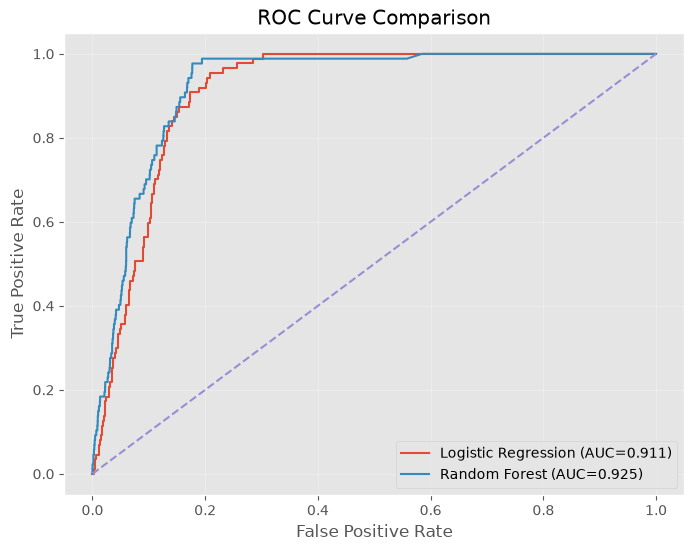

In [199]:
from sklearn.metrics import roc_curve


lr_fpr, lr_tpr, _ = roc_curve(

    y_test,

    y_prob

)


rf_fpr, rf_tpr, _ = roc_curve(

    y_test,

    rf_prob

)



plt.figure(figsize=(8,6))


plt.plot(

    lr_fpr,

    lr_tpr,

    label=f"Logistic Regression (AUC={roc_auc_score(y_test,y_prob):.3f})"

)


plt.plot(

    rf_fpr,

    rf_tpr,

    label=f"Random Forest (AUC={roc_auc_score(y_test,rf_prob):.3f})"

)


plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.show()

## Model Evaluation Summary

Both models achieved strong discrimination performance, with ROC-AUC values above 0.90.

Random Forest achieved the best overall performance, obtaining a higher ROC-AUC score compared with Logistic Regression. The tree-based model also improved precision and F1-score for the shot class, reducing the number of false positive predictions.

Logistic Regression achieved a higher recall, identifying more shot-ending possessions, but at the cost of generating more false positive predictions.

The Random Forest model was selected as the preferred model because it provided a better balance between identifying shot opportunities and limiting incorrect predictions.

# Final Conclusions

This study analysed possession-level characteristics associated with shot creation in women's football.

The exploratory analysis showed that spatial progression was the strongest factor differentiating possessions that resulted in shots from those that did not. Possessions ending with a shot consistently reached more advanced areas of the pitch, with end_x, start_x, and progression distance showing the largest differences between outcomes.

These findings indicate that territorial advancement and reaching dangerous attacking areas are the primary characteristics of successful possessions. Simply maintaining possession or increasing passing volume was not sufficient to explain shot creation, as the total number of passes did not show a statistically significant difference between outcomes.

Additional possession characteristics also contributed to distinguishing shot-ending possessions. Successful attacking sequences tended to involve more events, longer duration, more players, and more carries, suggesting that shots are often created through more developed collective actions.

The analysis of ball security variables showed that possessions ending with shots generally contained fewer turnovers, dispossessions, and miscontrols. This suggests that maintaining control and reducing errors are important components of creating attacking opportunities.

Machine learning models confirmed the findings from exploratory analysis. Both Logistic Regression and Random Forest achieved strong predictive performance, with ROC-AUC values above 0.90. Random Forest provided the best overall performance, achieving a ROC-AUC of approximately 0.925 and identifying spatial progression variables as the most important predictors.

Feature importance analysis showed that end_x was by far the strongest predictor, followed by progression distance and start_x. This confirms that the location and movement of the possession through the pitch are more influential than the simple quantity of actions performed.

Overall, the results suggest that shot creation in women's football is primarily driven by territorial progression, attacking positioning, and maintaining possession quality. These findings highlight the importance of advancing the ball into dangerous areas while preserving technical control during attacking sequences.

# Limitations and Future Work

Several limitations should be considered.

First, the analysis was performed at possession level, meaning that contextual information such as player quality, tactical system, match state, and opposition strength was not included.

Second, the dataset contained a strong imbalance between shot-ending and non-shot possessions, which required the use of class weighting during modelling.

Future work could incorporate additional contextual variables, including:
- match score state,
- player roles,
- defensive pressure intensity,
- opponent positioning,
- shot quality indicators.

Further models could also explore more advanced approaches such as gradient boosting methods or deep learning techniques for sequential event prediction.

In [200]:
import joblib

joblib.dump(
    rf_model,
    "shot_prediction_random_forest.pkl"
)

['shot_prediction_random_forest.pkl']

In [201]:
model = joblib.load(
    "shot_prediction_random_forest.pkl"
)